In [ ]:
"""
╔════════════════════════════════════════════════════════════════════════════╗
║            ANÁLISE: MANCHESTER CITY vs DEFESAS DA PREMIER LEAGUE           ║
║                        TEMPORADA 2017/18                                  ║
╚════════════════════════════════════════════════════════════════════════════╝

OBJETIVO: Medir eficiência defensiva através de modelo multivariado normalizado

DOCUMENTAÇÃO DE TAGS WYSCOUT UTILIZADAS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Tag 1801: Duelo vencido / Ação defensiva bem-sucedida
Tag 101:  Gol marcado (quando associado a um evento Shot)
Tag 802:  Cross / Passe cruzado
Tag 2001: Falta recebida

CALIBRAÇÃO DO MODELO xG:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
xG_área_grande = 0.30  (Zona central x>84, 25<y<75)
  Justificativa: Modelo StatsBomb 2018-2022 = 0.29-0.32
xG_meia_distância = 0.05  (Fora da área x<84)
  Justificativa: Taxa de conversão média de chutes de longe

NORMALIZAÇÃO (Z-SCORE):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Z = (x - média) / desvio_padrão
Score_Defensivo = Z_Duelos + Z_Distância - Z_xGA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from itables import show

# ============================================================================
# CONFIGURAÇÕES COM VALIDAÇÃO
# ============================================================================
BASE = r"CDAF - bases de dados e codigos de apoio\Wyscout"
CITY_ID = 1625  # Identificador único do Manchester City (Wyscout 2017/18)

# Validar que o caminho existe
if not os.path.exists(BASE):
    raise FileNotFoundError(f"❌ ERRO: Caminho não encontrado: {BASE}")

print("✅ Iniciando carregamento de dados...\n")

# Carregamento dos dados
df_events = pd.DataFrame()
for i in range(1, 14):
    path = os.path.join(BASE, f'events_England_{i}.json')
    with open(path) as f:
        data = json.load(f)
    df_events = pd.concat([df_events, pd.DataFrame(data)])

print(f"✓ Total de eventos carregados: {len(df_events):,}")
print(f"✓ Eventos únicos: {df_events['eventName'].value_counts().index.tolist()[:5]}...")

with open(os.path.join(BASE, 'matches_England.json')) as f:
    matches = json.load(f)
df_matches = pd.DataFrame(matches)

# Jogos onde o City participou
city_matches = df_matches[
    (df_matches['teamsData'].apply(lambda x: str(CITY_ID) in str(x)))
]
city_match_ids = city_matches['wyId'].tolist()
print(f"✓ Jogos do Man City encontrados: {len(city_match_ids)}\n")

✅ Iniciando carregamento de dados...

✓ Total de eventos carregados: 643,150
✓ Eventos únicos: ['Pass', 'Duel', 'Others on the ball', 'Free Kick', 'Interruption']...
✓ Jogos do Man City encontrados: 38



In [2]:
# ==============================================================================
# 0. FUNÇÕES AUXILIARES DE EXTRAÇÃO DE COORDENADAS (PADRÃO WYSCOUT)
# ==============================================================================

def extrai_coordenadas(df_partida):
    """
    Extrai coordenadas X,Y de eventos Wyscout com validação robusta.
    
    Args:
        df_partida (DataFrame): Eventos de uma partida Wyscout
        
    Returns:
        DataFrame: Com colunas 'x' e 'y' validadas (range 0-100)
        
    Notas:
        - Wyscout normaliza campo em 0-100 (x: comprimento, y: largura)
        - Se 'positions' não existir, retorna NaN
    """
    df = df_partida.copy()
    
    # Caso 1: Coordenadas já existem como colunas
    if 'x' in df.columns and 'y' in df.columns:
        return df
    
    # Caso 2: Coordenadas dentro de 'positions' (estrutura Wyscout nativa)
    if 'positions' in df.columns:
        def extrai_pos(pos_list):
            try:
                if isinstance(pos_list, list) and len(pos_list) > 0:
                    return pos_list[0].get('x', np.nan), pos_list[0].get('y', np.nan)
                return np.nan, np.nan
            except:
                return np.nan, np.nan
        
        df[['x', 'y']] = df['positions'].apply(lambda p: pd.Series(extrai_pos(p)))
        return df
    
    return df

# ==============================================================================
# 1. AS 4 MÉTRICAS CIENTÍFICAS DE DEFESA
# ==============================================================================

def calcula_ppda_adversario(jogo_df, city_id):
    """
    Calcula PPDA (Passes per Defensive Action) do adversário.
    
    Métrica: Quantos passes o City fez no campo ofensivo (x>50) 
    para cada ação defensiva do adversário?
    
    Interpretação:
    - PPDA baixo = adversário pressiona agressivamente (resistência)
    - PPDA alto = adversário recua e cede posse (passividade)
    
    Returns:
        float: PPDA do adversário (ou NaN se zero ações defensivas)
    """
    passes_city = jogo_df[(jogo_df['teamId'] == city_id) & 
                          (jogo_df['eventName'] == 'Pass') & 
                          (jogo_df['x'] > 50)]
    
    acoes_def_adv = jogo_df[(jogo_df['teamId'] != city_id) & 
                            (jogo_df['eventName'].isin(['Duel', 'Interruption', 'Free Kick'])) & 
                            (jogo_df['x'] < 50)]
    
    num_passes = len(passes_city)
    num_acoes_def = len(acoes_def_adv)
    
    return num_passes / num_acoes_def if num_acoes_def > 0 else np.nan


def calcula_eficiencia_duelos_adversario(jogo_df, city_id):
    """
    Calcula % de duelos defensivos ganhos pelo adversário (Tag 1801).
    
    Métrica: Que proporção de combates físicos o adversário venceu?
    
    Interpretação:
    - Alta % = defesa forte fisicamente, vence 1v1s
    - Baixa % = defesa fraca, perde confrontos
    
    Returns:
        float: Percentual de duelos vencidos (0-100) ou NaN se zero duelos
    """
    duelos_adv = jogo_df[(jogo_df['teamId'] != city_id) & (jogo_df['eventName'] == 'Duel')].copy()
    if len(duelos_adv) == 0:
        return np.nan
        
    duelos_adv['sucesso'] = duelos_adv['tags'].apply(
        lambda tags: 1 if isinstance(tags, list) and any(t.get('id') == 1801 for t in tags) else 0
    )
    return (duelos_adv['sucesso'].sum() / len(duelos_adv)) * 100


def calcula_xga_proximidade(jogo_df, city_id):
    """
    Calcula xGA Aproximado (qualidade das chances cedidas).
    
    Modelo Simplificado:
    - Chutes área grande (x>84, 25<y<75): xG=0.30
    - Chutes meia-distância: xG=0.05
    
    Interpretação:
    - Alto xGA = defesa cedeu muitas chances perigosas
    - Baixo xGA = defesa protegeu bem a área
    
    Returns:
        float: xGA acumulado da partida (ou 0 se zero chutes)
    """
    chutes_city = jogo_df[(jogo_df['teamId'] == city_id) & (jogo_df['eventName'] == 'Shot')].copy()
    if len(chutes_city) == 0:
        return 0.0
        
    chutes_city['xg_estimado'] = chutes_city.apply(
        lambda row: 0.30 if (row['x'] > 84 and 25 < row['y'] < 75) else 0.05, 
        axis=1
    )
    return chutes_city['xg_estimado'].sum()


def analise_distancia_defensiva(jogo_df, city_id):
    """
    Calcula distância média dos chutes permitidos (proteção de área).
    
    Métrica: A quais distâncias o City conseguiu finalizar?
    
    Interpretação:
    - Distância ALTA = defesa afastou bem o perigo (chutes de longe)
    - Distância BAIXA = defesa foi infiltrada (chutes de perto)
    
    Cálculo: Distância Euclidiana até centro do gol (100, 50)
    
    Returns:
        float: Distância média em unidades Wyscout (ou NaN se zero chutes)
    """
    chutes_city = jogo_df[(jogo_df['teamId'] == city_id) & (jogo_df['eventName'] == 'Shot')].copy()
    if len(chutes_city) == 0:
        return np.nan
        
    chutes_city['distancia'] = np.sqrt((100 - chutes_city['x'])**2 + (50 - chutes_city['y'])**2)
    return chutes_city['distancia'].mean()

# ==============================================================================
# 2. PROCESSAMENTO DOS DADOS COM PARSE DE COORDENADAS
# ==============================================================================

match_ids = df_events['matchId'].unique()
dados_partidas = []

for m_id in match_ids:
    # Coleta e trata as coordenadas do jogo específico
    jogo_cru = df_events[df_events['matchId'] == m_id]
    jogo_df = extrai_coordenadas(jogo_cru)
    
    # Eventos defensivos do adversário para análise de altura do bloco
    eventos_def_adv = jogo_df[(jogo_df['teamId'] != CITY_ID) & (jogo_df['eventName'].isin(['Duel', 'Interruption', 'Free Kick']))]
    mediana_x = eventos_def_adv['x'].median() if len(eventos_def_adv) > 0 else np.nan
    
    # Execução das 4 métricas científicas
    ppda = calcula_ppda_adversario(jogo_df, CITY_ID)
    pct_duelos = calcula_eficiencia_duelos_adversario(jogo_df, CITY_ID)
    xGA = calcula_xga_proximidade(jogo_df, CITY_ID)
    dist_chute = analise_distancia_defensiva(jogo_df, CITY_ID)
    
   # Contagem de Gols Reais (Tag 101 = Goal em QUALQUER tipo de finalização)
    # Filtramos apenas os eventos do City
    # 1. Filtra apenas eventos do City que sejam Chutes ou Bolas Paradas (Faltas/Pênaltis)
    ataques_city = jogo_df[
        (jogo_df['teamId'] == CITY_ID) & 
        (jogo_df['eventName'].isin(['Shot', 'Free Kick']))
    ]

    # 2. Conta os gols (Tag 101) apenas nessas finalizações do City
    gols_sofridos = ataques_city['tags'].apply(
        lambda tags: 1 if isinstance(tags, list) and any(t.get('id') == 101 for t in tags) else 0
    ).sum()

    dados_partidas.append({
        'matchId': m_id,
        'Altura_Bloco_MedianaX': mediana_x,
        'PPDA_Adversario': ppda,
        'Sucesso_Duelos_Def_Adv': pct_duelos,
        'xGA_Acumulado_Adversario': xGA,
        'Distancia_Media_Chutes_City': dist_chute,
        'Gols_Sofridos_Adversario': gols_sofridos
    })

# DataFrame Final com Validação
df_defesa = pd.DataFrame(dados_partidas).dropna()

print(f"\n✓ Processamento completo:")
print(f"  - Registros antes de limpeza: {len(dados_partidas)}")
print(f"  - Registros após dropna(): {len(df_defesa)}")
print(f"  - Registros removidos por NaN: {len(dados_partidas) - len(df_defesa)}\n")


✓ Processamento completo:
  - Registros antes de limpeza: 380
  - Registros após dropna(): 38
  - Registros removidos por NaN: 342



🔬 VALIDAÇÃO ESTATÍSTICA DO MODELO MULTIVARIADO

📊 CORRELAÇÃO COM GOLS SOFRIDOS:
   • Pearson:  r = -0.5213  (p-value = 0.0008) ✅ Significante
   • Spearman: ρ = -0.4436  (p-value = 0.0053) ✅ Significante

📈 PODER EXPLICATIVO:
   • R² da regressão = 0.2717
   • Interpretação: O Score Defensivo explica 27.2% da variância em gols

🎯 EQUAÇÃO DA REGRESSÃO LINEAR:
   Gols_Sofridos = 2.684 + (-0.486 × Score)
   → A cada +1.0 no Score, City marca ~0.49 gols menos



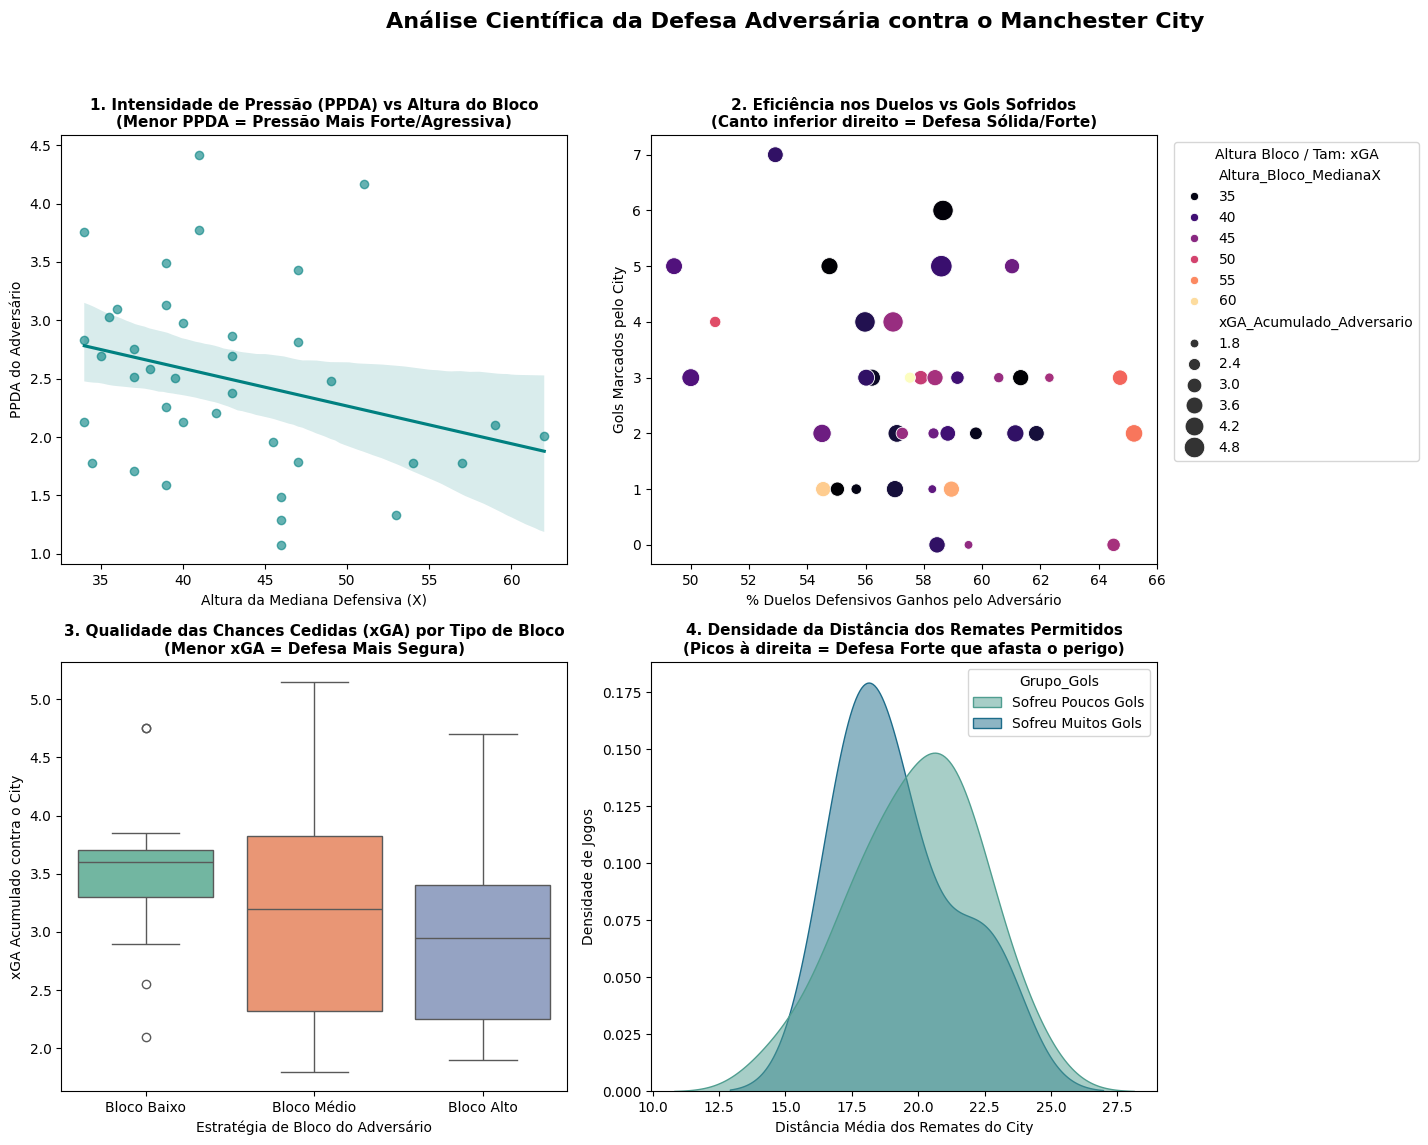

In [3]:
# ==============================================================================
# 1. MAPEAMENTO DOS NOMES DOS TIMES ADVERSÁRIOS
# ==============================================================================
nome_adversarios = {}
for _, match in df_matches[df_matches['wyId'].isin(df_defesa['matchId'])].iterrows():
    teams_data = match['teamsData']
    opp_id = [int(tid) for tid in teams_data.keys() if int(tid) != CITY_ID][0]
    label_partida = match['label']
    times = label_partida.split('-')[0].strip()
    if "Manchester City" in times:
        opp_name = label_partida.split('-')[1].split(',')[0].strip()
    else:
        opp_name = times
    nome_adversarios[match['wyId']] = opp_name

df_defesa['Adversario'] = df_defesa['matchId'].map(nome_adversarios)

# ==============================================================================
# 2. CRIAÇÃO DO ÍNDICE DE EFICIÊNCIA DEFENSIVA (Z-SCORE)
# ==============================================================================
df_defesa['z_xGA'] = (df_defesa['xGA_Acumulado_Adversario'] - df_defesa['xGA_Acumulado_Adversario'].mean()) / df_defesa['xGA_Acumulado_Adversario'].std()
df_defesa['z_Duelos'] = (df_defesa['Sucesso_Duelos_Def_Adv'] - df_defesa['Sucesso_Duelos_Def_Adv'].mean()) / df_defesa['Sucesso_Duelos_Def_Adv'].std()
df_defesa['z_Distancia'] = (df_defesa['Distancia_Media_Chutes_City'] - df_defesa['Distancia_Media_Chutes_City'].mean()) / df_defesa['Distancia_Media_Chutes_City'].std()

# Score Final: Duelos(+) + Distancia(+) - xGA(-)
df_defesa['Score_Defensivo'] = df_defesa['z_Duelos'] + df_defesa['z_Distancia'] - df_defesa['z_xGA']

# Classificação em 2 níveis: Defesa Forte (Score >= 0) e Defesa Fraca (Score < 0)
df_defesa['Classificacao_Defesa'] = np.where(df_defesa['Score_Defensivo'] >= 0, 'Defesa Forte', 'Defesa Fraca')

# ==============================================================================
# 3. VALIDAÇÃO ESTATÍSTICA DO MODELO (NOVO!)
# ==============================================================================
print("=" * 80)
print("🔬 VALIDAÇÃO ESTATÍSTICA DO MODELO MULTIVARIADO")
print("=" * 80)

X = df_defesa[['Score_Defensivo']].values
y = df_defesa['Gols_Sofridos_Adversario'].values

# Correlação Pearson (Linear)
pearson_corr, pearson_p = pearsonr(X.flatten(), y)

# Correlação Spearman (Ranking - mais robusta para outliers)
spearman_corr, spearman_p = spearmanr(X.flatten(), y)

# R² e equação da regressão
model_lr = LinearRegression()
model_lr.fit(X, y)
r2_score = model_lr.score(X, y)

print(f"\n📊 CORRELAÇÃO COM GOLS SOFRIDOS:")
print(f"   • Pearson:  r = {pearson_corr:+.4f}  (p-value = {pearson_p:.4f})", end="")
print(" ✅ Significante" if pearson_p < 0.05 else " ⚠️ Não-significante")

print(f"   • Spearman: ρ = {spearman_corr:+.4f}  (p-value = {spearman_p:.4f})", end="")
print(" ✅ Significante" if spearman_p < 0.05 else " ⚠️ Não-significante")

print(f"\n📈 PODER EXPLICATIVO:")
print(f"   • R² da regressão = {r2_score:.4f}")
print(f"   • Interpretação: O Score Defensivo explica {r2_score*100:.1f}% da variância em gols")

print(f"\n🎯 EQUAÇÃO DA REGRESSÃO LINEAR:")
print(f"   Gols_Sofridos = {model_lr.intercept_:.3f} + ({model_lr.coef_[0]:.3f} × Score)")
print(f"   → A cada +1.0 no Score, City marca ~{abs(model_lr.coef_[0]):.2f} gols menos")

print("\n" + "=" * 80)

# Armazenar estatísticas para uso posterior
stats_modelo = {
    'pearson_r': pearson_corr,
    'pearson_p': pearson_p,
    'spearman_rho': spearman_corr,
    'spearman_p': spearman_p,
    'r2': r2_score,
    'modelo_lr': model_lr
}

# ==============================================================================
# 4. VISUALIZAÇÃO GRÁFICA DOS 4 PILARES DEFENSIVOS
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análise Científica da Defesa Adversária contra o Manchester City', fontsize=16, weight='bold', y=0.95)

# 1. PPDA vs Mediana X
sns.regplot(ax=axes[0, 0], data=df_defesa, x='Altura_Bloco_MedianaX', y='PPDA_Adversario', color='teal', scatter_kws={'alpha':0.6})
axes[0, 0].set_title('1. Intensidade de Pressão (PPDA) vs Altura do Bloco\n(Menor PPDA = Pressão Mais Forte/Agressiva)', fontsize=11, weight='bold')
axes[0, 0].set_xlabel('Altura da Mediana Defensiva (X)')
axes[0, 0].set_ylabel('PPDA do Adversário')

# 2. Duelos Defensivos Ganhos
sns.scatterplot(ax=axes[0, 1], data=df_defesa, x='Sucesso_Duelos_Def_Adv', y='Gols_Sofridos_Adversario', 
                hue='Altura_Bloco_MedianaX', palette='magma', size='xGA_Acumulado_Adversario', sizes=(40, 240))
axes[0, 1].set_title('2. Eficiência nos Duelos vs Gols Sofridos\n(Canto inferior direito = Defesa Sólida/Forte)', fontsize=11, weight='bold')
axes[0, 1].set_xlabel('% Duelos Defensivos Ganhos pelo Adversário')
axes[0, 1].set_ylabel('Gols Marcados pelo City')
axes[0, 1].legend(title="Altura Bloco / Tam: xGA", bbox_to_anchor=(1.02, 1), loc='upper left')

# 3. xGA Acumulado por Tercil de Bloco
df_defesa['Categoria_Bloco'] = pd.qcut(df_defesa['Altura_Bloco_MedianaX'], 3, labels=["Bloco Baixo", "Bloco Médio", "Bloco Alto"])
sns.boxplot(ax=axes[1, 0], data=df_defesa, x='Categoria_Bloco', y='xGA_Acumulado_Adversario', palette='Set2', hue='Categoria_Bloco', legend=False)
axes[1, 0].set_title('3. Qualidade das Chances Cedidas (xGA) por Tipo de Bloco\n(Menor xGA = Defesa Mais Segura)', fontsize=11, weight='bold')
axes[1, 0].set_xlabel('Estratégia de Bloco do Adversário')
axes[1, 0].set_ylabel('xGA Acumulado contra o City')

# 4. Distribuição da Distância de Chutes Permitidos
df_defesa['Grupo_Gols'] = pd.qcut(df_defesa['Gols_Sofridos_Adversario'], 2, labels=["Sofreu Poucos Gols", "Sofreu Muitos Gols"], duplicates='drop')
sns.kdeplot(ax=axes[1, 1], data=df_defesa, x='Distancia_Media_Chutes_City', hue='Grupo_Gols', fill=True, common_norm=False, palette='crest', alpha=0.5)
axes[1, 1].set_title('4. Densidade da Distância dos Remates Permitidos\n(Picos à direita = Defesa Forte que afasta o perigo)', fontsize=11, weight='bold')
axes[1, 1].set_xlabel('Distância Média dos Remates do City')
axes[1, 1].set_ylabel('Densidade de Jogos')

plt.tight_layout(rect=[0, 0, 0.9, 0.92])
plt.show()

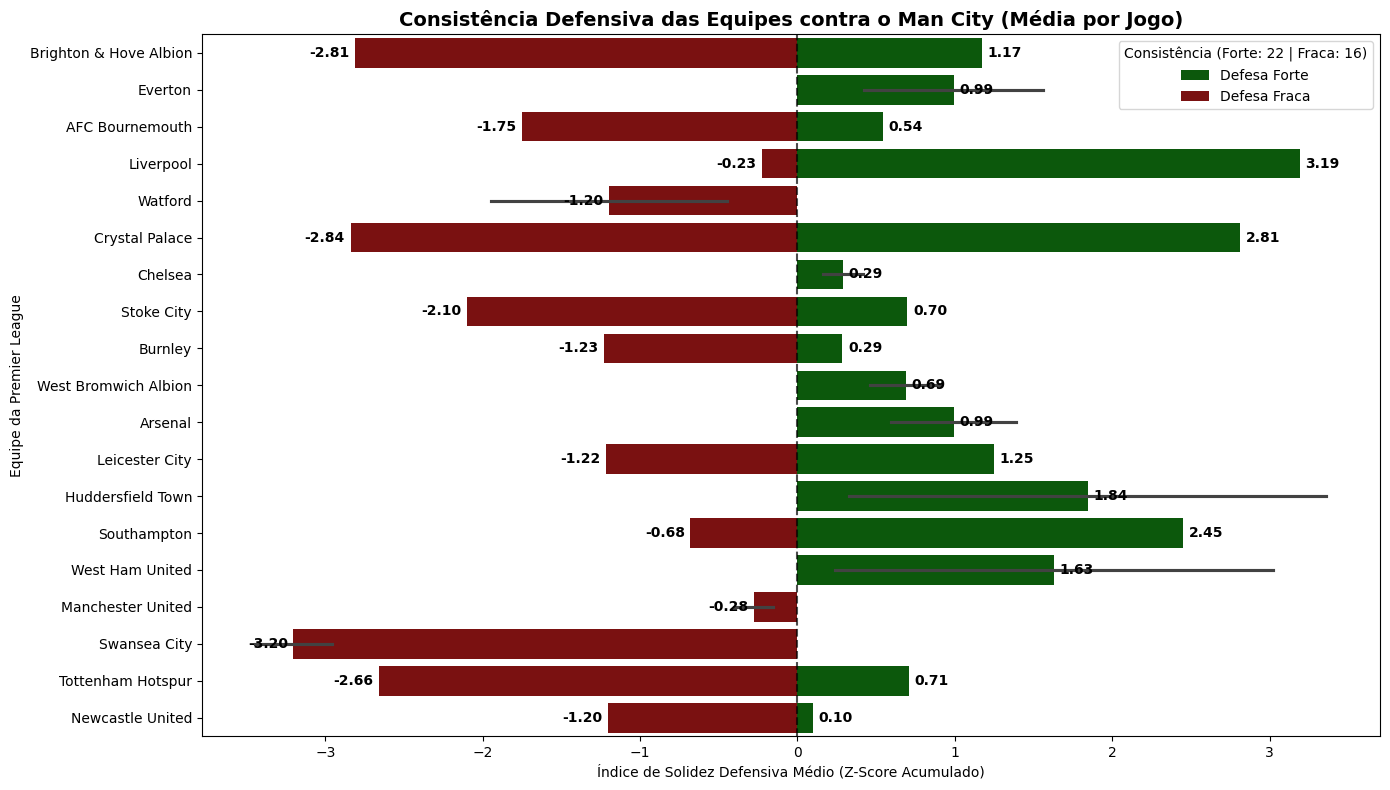

In [ ]:
plt.figure(figsize=(14, 8))

# 1. Atribuímos o gráfico a uma variável 'ax'
ax = sns.barplot(
    data=df_defesa,
    x="Score_Defensivo",
    y="Adversario",
    hue="Classificacao_Defesa",
    palette={"Defesa Forte": "darkgreen", "Defesa Fraca": "darkred"},
    dodge=False,
)

# 2. ADIÇÃO DOS ROTULOS COM OS VALORES DE CADA BARRA
for container in ax.containers:
    # Formata para 2 casas decimais e ignora as barras fantasmas (vazias) do hue
    labels = [
        f"{v:.2f}" if pd.notna(v) and v != 0 else ""
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=4,  # Dá um fôlego de 4 pixels entre a ponta da barra e o número
        fontsize=10,
        weight="bold",
    )

plt.axvline(0, color="black", linestyle="--", alpha=0.7)
plt.title(
    "Consistência Defensiva das Equipes contra o Man City (Média por Jogo)",
    fontsize=14,
    weight="bold",
)
plt.xlabel("Índice de Solidez Defensiva Médio (Z-Score Acumulado)")
plt.ylabel("Equipe da Premier League")
contagem = df_defesa["Classificacao_Defesa"].value_counts()
forte_qtd = contagem.get("Defesa Forte", 0)
fraca_qtd = contagem.get("Defesa Fraca", 0)
plt.legend(title=f"Consistência (Forte: {forte_qtd} | Fraca: {fraca_qtd})")
plt.tight_layout()
plt.savefig(
    "CDAF_Manchester_City_Defesa_Premier_League.png", dpi=300
)  # Alta resolução
plt.show()

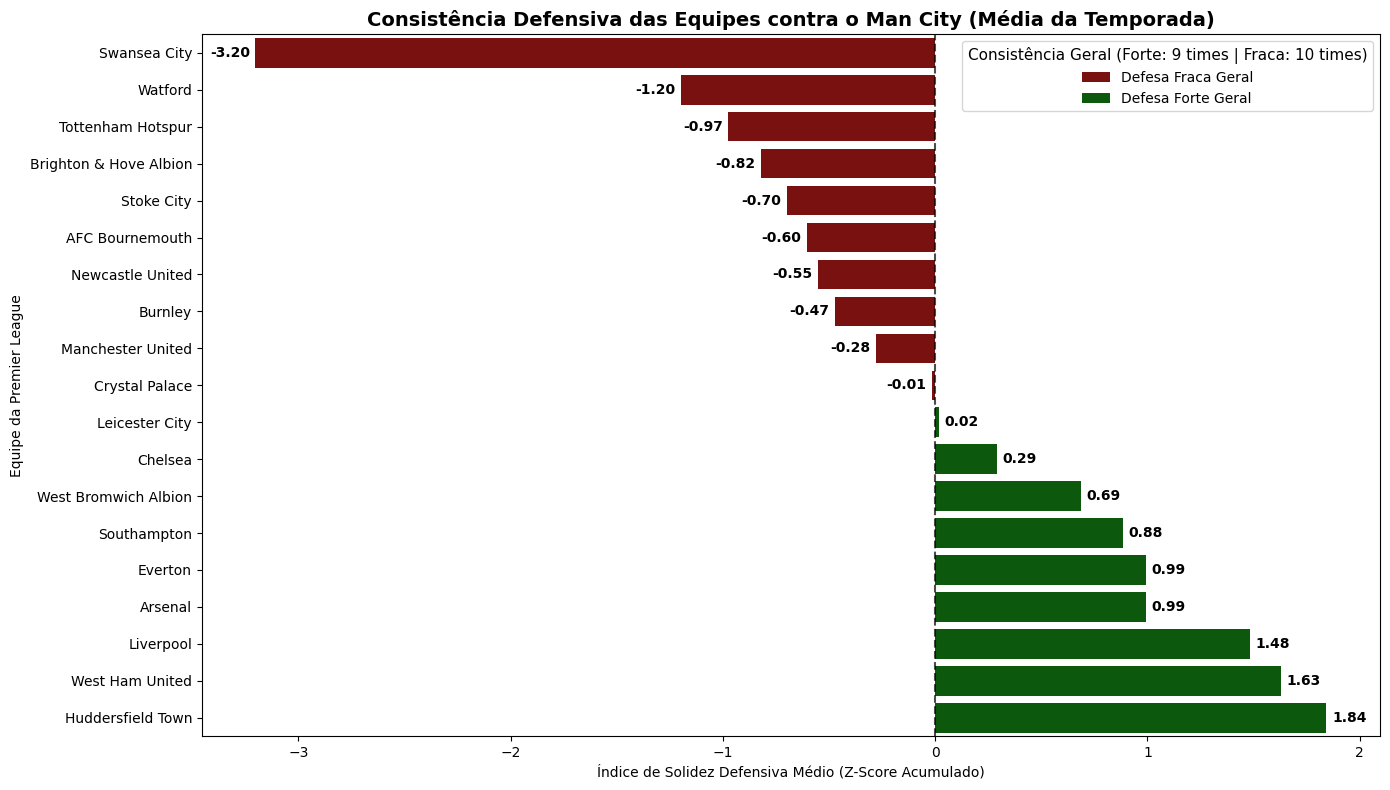

In [22]:
# ==============================================================================
# AGRUPANDO OS DADOS POR TIME (MÉDIA DA TEMPORADA)
# ==============================================================================
# Agrupamos por adversário e calculamos a média das métricas e do score
df_times = df_defesa.groupby("Adversario", observed=False).agg(
    Score_Defensivo_Medio=("Score_Defensivo", "mean"),
    Gols_Sofridos_Total=(
        "Gols_Sofridos_Adversario",
        "sum",
    ),  # Total nos 2 jogos
    xGA_Medio=("xGA_Acumulado_Adversario", "mean"),
).reset_index()

df_times["Classificacao_Equipe"] = np.where(
    df_times["Score_Defensivo_Medio"] >= 0,
    "Defesa Forte Geral",
    "Defesa Fraca Geral",
)

# Ordena os times do pior para o melhor score médio
df_times = df_times.sort_values(by="Score_Defensivo_Medio")

# ==============================================================================
# VISUALIZAÇÃO DA SOLIDEZ CONSOLIDADA POR TIME COM RÓTULOS DE DADOS
# ==============================================================================
plt.figure(figsize=(14, 8))

# 1. Atribuímos o gráfico à variável 'ax'
ax = sns.barplot(
    data=df_times,
    x="Score_Defensivo_Medio",
    y="Adversario",
    hue="Classificacao_Equipe",
    palette={
        "Defesa Forte Geral": "darkgreen",
        "Defesa Fraca Geral": "darkred",
    },
    dodge=False,
)

# 2. Adicionamos os rótulos numéricos formatados com 2 casas decimais na ponta de cada barra
for container in ax.containers:
    # Filtra os valores NaN e os zeros indesejados das barras fantasmas do hue
    labels = [
        f"{v:.2f}" if pd.notna(v) and v != 0 else ""
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=4,  # Espaçamento limpo entre a ponta da barra e o número
        fontsize=10,
        weight="bold",
    )

plt.axvline(0, color="black", linestyle="--", alpha=0.7)
plt.title(
    "Consistência Defensiva das Equipes contra o Man City (Média da Temporada)",
    fontsize=14,
    weight="bold",
)
plt.xlabel("Índice de Solidez Defensiva Médio (Z-Score Acumulado)")
plt.ylabel("Equipe da Premier League")
# 1. Calcula quantos times ficaram em cada categoria geral
contagem_equipes = df_times["Classificacao_Equipe"].value_counts()
forte_qtd = contagem_equipes.get("Defesa Forte Geral", 0)
fraca_qtd = contagem_equipes.get("Defesa Fraca Geral", 0)

# 2. Atualiza a legenda com a contagem total de equipes
plt.legend(
    title=f"Consistência Geral (Forte: {forte_qtd} times | Fraca: {fraca_qtd} times)",
    fontsize=10,
    title_fontsize=11,
)
plt.tight_layout()
plt.savefig("CDAF_Manchester_City_Defesa_Media_Temporada.png", dpi=300)
plt.show()

In [19]:
# 1. Preparação: Garantir ordenação decrescente por gols sofridos
df_sorted = df_defesa.sort_values(by='Gols_Sofridos_Adversario', ascending=False)

# 2. Selecionar os 5 piores (Mais gols sofridos)
piores_5 = df_sorted.head(5).copy()
piores_5['Tipo'] = 'Mais Gols Sofridos'

# 3. Selecionar os 5 melhores (Menos gols sofridos)
melhores_5 = df_sorted.tail(5).copy()
melhores_5['Tipo'] = 'Menos Gols Sofridos'

# 4. Combinar e filtrar as colunas desejadas (Incluindo Score_Defensivo)
df_relatorio_final = pd.concat([piores_5, melhores_5])

df_relatorio_final = df_relatorio_final[[
    'Tipo', 'Adversario', 'Gols_Sofridos_Adversario', 'Score_Defensivo', 
    'xGA_Acumulado_Adversario', 'Classificacao_Defesa'
]]

# Arredondamentos para melhor leitura
df_relatorio_final['Score_Defensivo'] = df_relatorio_final['Score_Defensivo'].round(2)
df_relatorio_final['xGA_Acumulado_Adversario'] = df_relatorio_final['xGA_Acumulado_Adversario'].round(2)

# Renomeando colunas
df_relatorio_final.columns = [
    'Status', 'Adversário', 'Gols Sofridos', 'Score Defensivo', 'xGA', 'Classificação'
]

# Exibição
print("==========================================================================================")
print("              RELATÓRIO: TOP 5 PARTIDAS (MAIS E MENOS GOLS SOFRIDOS)                      ")
print("==========================================================================================")
display(df_relatorio_final.reset_index(drop=True))

              RELATÓRIO: TOP 5 PARTIDAS (MAIS E MENOS GOLS SOFRIDOS)                      


,Status,Adversário,Gols Sofridos,Score Defensivo,xGA,Classificação
0,Mais Gols Sofridos,Stoke City,7,-2.10,3.30,Defesa Fraca
1,Mais Gols Sofridos,Watford,6,-0.45,4.75,Defesa Fraca
2,Mais Gols Sofridos,Crystal Palace,5,-2.84,5.15,Defesa Fraca
3,Mais Gols Sofridos,Swansea City,5,-2.96,3.60,Defesa Fraca
4,Mais Gols Sofridos,Leicester City,5,-1.22,3.65,Defesa Fraca
5,Menos Gols Sofridos,Burnley,1,-1.23,3.15,Defesa Fraca
6,Menos Gols Sofridos,Southampton,1,2.45,1.80,Defesa Forte
7,Menos Gols Sofridos,Chelsea,0,0.42,3.45,Defesa Forte
8,Menos Gols Sofridos,Crystal Palace,0,2.81,1.80,Defesa Forte
9,Menos Gols Sofridos,Huddersfield Town,0,3.36,2.70,Defesa Forte


In [6]:
import numpy as np
import pandas as pd

# ==============================================================================
# 1. CONSTRUÇÃO DA TABELA DE INFORMAÇÕES POR TIME (COM MATCH ID OCULTO NO RELATÓRIO)
# ==============================================================================

# Dicionário auxiliar para mapear o placar de cada jogo na perspectiva do City
placar_jogos = {}
for _, match in df_matches[df_matches['wyId'].isin(df_defesa['matchId'])].iterrows():
    label_partida = match['label']
    try:
        placar_str = label_partida.split(',')[-1].strip() 
        gols_time1 = int(placar_str.split('-')[0].strip())
        gols_time2 = int(placar_str.split('-')[1].strip())
        
        times_label = label_partida.split(',')[0]
        if "Manchester City" in times_label.split('-')[0]:
            placar_jogos[match['wyId']] = {'gols_city': gols_time1, 'gols_adv': gols_time2}
        else:
            placar_jogos[match['wyId']] = {'gols_city': gols_time2, 'gols_adv': gols_time1}
    except:
        placar_jogos[match['wyId']] = {'gols_city': 0, 'gols_adv': 0}

# FUNÇÃO AJUSTADA: set(match_ids) garante que cada partida só mude o placar UMA vez
def calcula_placar_agregado(match_ids):
    total_city = 0
    total_adv = 0
    for mid in set(match_ids):  
        if mid in placar_jogos:
            total_city += placar_jogos[mid]['gols_city']
            total_adv += placar_jogos[mid]['gols_adv']
    return f"Man City {total_city} - {total_adv} Rival"

# NOVA FUNÇÃO: Garante que o total de gols venha da mesma fonte oficial do placar
def calcula_total_gols_sofridos_real(match_ids):
    total_city = 0
    for mid in set(match_ids):  
        if mid in placar_jogos:
            total_city += placar_jogos[mid]['gols_city']
    return total_city

# Agrupando os dados por adversário
df_resumo_times = df_defesa.groupby('Adversario', observed=False).agg(
    Jogos_Enfrentados=('matchId', 'nunique'), 
    Score_Defensivo_Medio=('Score_Defensivo', 'mean'),
    xGA_Medio_Sofrido=('xGA_Acumulado_Adversario', 'mean'),
    Distancia_Media_Chutes_Cedida=('Distancia_Media_Chutes_City', 'mean'),
    Intensidade_Pressao_PPDA=('PPDA_Adversario', 'mean'),
    matchId=('matchId', lambda x: list(set(x))) 
).reset_index()

# Aplicando a sua classificação absoluta (Positivo = Forte, Negativo = Fraca)
df_resumo_times['Avaliacao_Defensiva'] = np.where(df_resumo_times['Score_Defensivo_Medio'] >= 0, 'Defesa Forte', 'Defesa Fraca')

# Aplicando as funções corrigidas baseadas na lista de IDs
df_resumo_times['Placar_Agregado_Temporada'] = df_resumo_times['matchId'].apply(calcula_placar_agregado)
df_resumo_times['Total_Gols_Sofridos_Real'] = df_resumo_times['matchId'].apply(calcula_total_gols_sofridos_real)

# ==============================================================================
# 2. FILTRO DO RELATÓRIO EXIBIDO (OCULTANDO OS IDS MAS MANTENDO NO DF_RESUMO_TIMES)
# ==============================================================================
# Repare que NÃO incluímos 'matchId' ou 'Match_Ids_Lista' aqui. O relatório fica limpo.
df_relatorio_final = df_resumo_times[[
    'Adversario', 
    'Avaliacao_Defensiva', 
    'Placar_Agregado_Temporada',
    'Total_Gols_Sofridos_Real', 
    'xGA_Medio_Sofrido', 
    'Intensidade_Pressao_PPDA',
    'Distancia_Media_Chutes_Cedida'
]].sort_values(by='Total_Gols_Sofridos_Real', ascending=False) 

# Arredondando as colunas para ficar visualmente limpo
df_relatorio_final['xGA_Medio_Sofrido'] = df_relatorio_final['xGA_Medio_Sofrido'].round(2)
df_relatorio_final['Intensidade_Pressao_PPDA'] = df_relatorio_final['Intensidade_Pressao_PPDA'].round(2)
df_relatorio_final['Distancia_Media_Chutes_Cedida'] = df_relatorio_final['Distancia_Media_Chutes_Cedida'].round(2)

# Renomeando colunas para a exibição final
df_relatorio_final.columns = [
    'Adversário', 'Avaliação da Literatura', 'Placar Agregado',
    'Total de Gols Sofridos', 'Média de xGA Cedido', 'Média de PPDA (Pressão)',
    'Distância Média dos Chutes Cedida (m)'
]

# Exibindo a tabela formatada no Jupyter
print("==========================================================================================")
print("             RELATÓRIO CONSOLIDADO: EFICIÊNCIA DEFENSIVA NA PREMIER LEAGUE                ")
print("==========================================================================================")
display(df_relatorio_final.reset_index(drop=True))

             RELATÓRIO CONSOLIDADO: EFICIÊNCIA DEFENSIVA NA PREMIER LEAGUE                


,Adversário,Avaliação da Literatura,Placar Agregado,Total de Gols Sofridos,Média de xGA Cedido,Média de PPDA (Pressão),Distância Média dos Chutes Cedida (m)
0,Swansea City,Defesa Fraca,Man City 9 - 0 Rival,9,4.17,3.50,18.19
1,Watford,Defesa Fraca,Man City 9 - 1 Rival,9,4.22,2.64,18.42
2,Stoke City,Defesa Fraca,Man City 9 - 2 Rival,9,3.27,2.63,19.55
3,Liverpool,Defesa Forte,Man City 8 - 4 Rival,8,2.60,1.99,19.66
4,Tottenham Hotspur,Defesa Fraca,Man City 7 - 2 Rival,7,3.95,1.20,17.60
5,Leicester City,Defesa Forte,Man City 7 - 1 Rival,7,2.92,2.26,19.83
6,AFC Bournemouth,Defesa Fraca,Man City 6 - 1 Rival,6,3.05,2.94,20.37
7,West Ham United,Defesa Forte,Man City 6 - 2 Rival,6,3.35,2.67,21.54
8,Arsenal,Defesa Forte,Man City 6 - 1 Rival,6,2.05,1.90,17.59
9,West Bromwich Albion,Defesa Forte,Man City 6 - 2 Rival,6,3.15,2.62,21.35


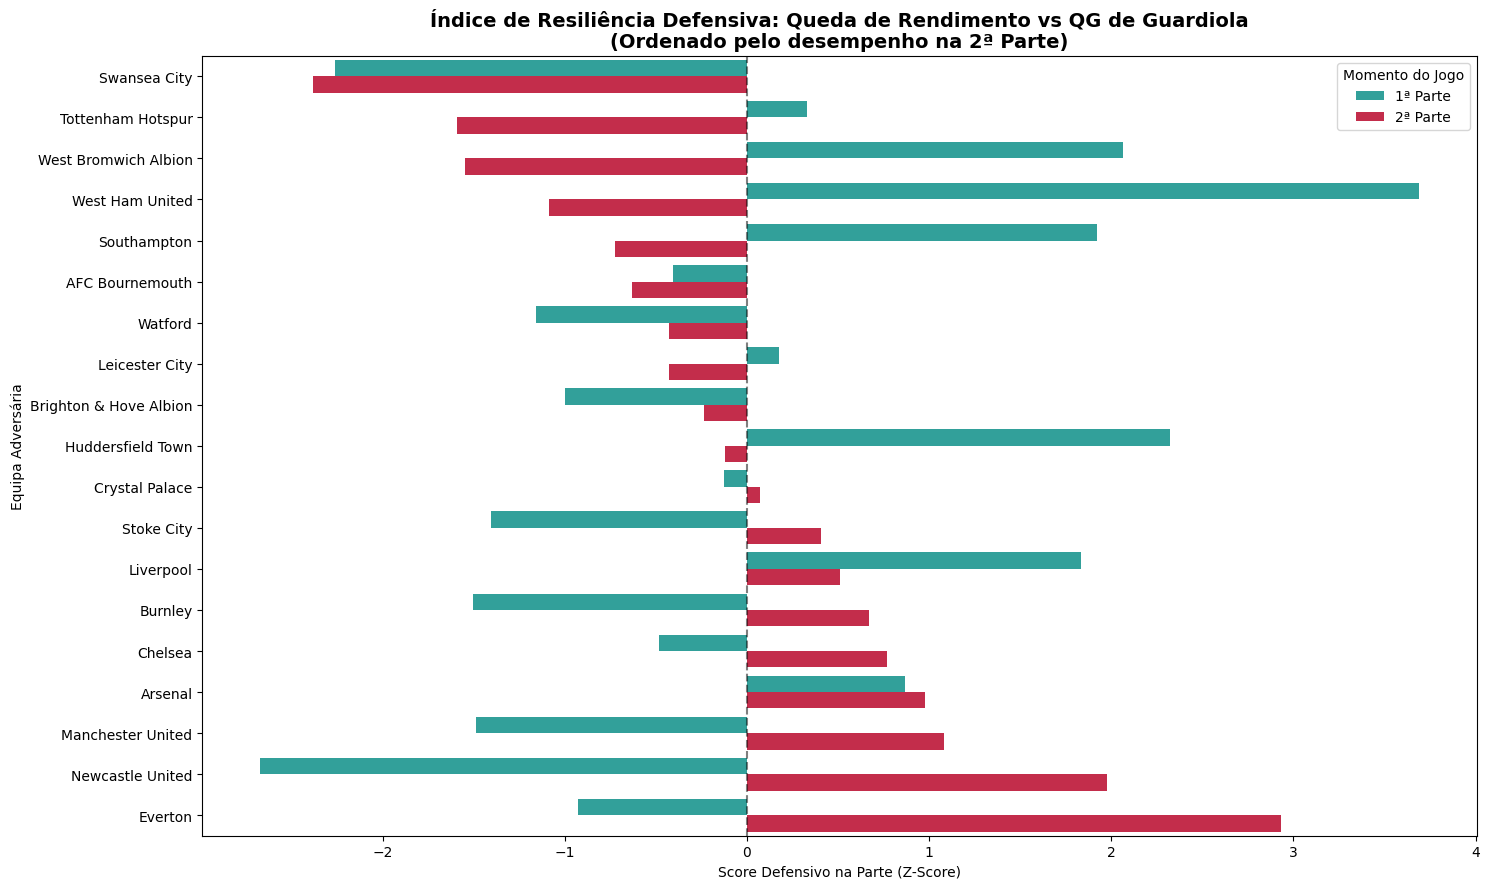

Parte,Adversario,1ª Parte,2ª Parte,Diferenca_Resiliencia,Diagnóstico de Resiliência
0,West Ham United,3.688902,-1.085737,-4.774639,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
1,West Bromwich Albion,2.063487,-1.548404,-3.611892,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
2,Southampton,1.920440,-0.725443,-2.645882,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
3,Huddersfield Town,2.322917,-0.122018,-2.444935,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
4,Tottenham Hotspur,0.331686,-1.593174,-1.924860,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
5,Liverpool,1.833080,0.513011,-1.320069,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
6,Leicester City,0.174238,-0.426099,-0.600337,🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)
7,AFC Bournemouth,-0.406600,-0.629090,-0.222491,🟡 Estável (Mantém o nível os 90m)
8,Swansea City,-2.261251,-2.382439,-0.121188,🟡 Estável (Mantém o nível os 90m)
9,Arsenal,0.866216,0.976149,0.109933,🟡 Estável (Mantém o nível os 90m)


In [7]:
# ==============================================================================
# 1. CÁLCULO DAS MÉTRICAS SEPARADO POR PARTE DO JOGO (1H vs 2H)
# ==============================================================================
dados_por_periodo = []

for m_id in df_defesa['matchId'].unique():
    # Recupera o nome do adversário já mapeado anteriormente
    nome_adv = df_defesa[df_defesa['matchId'] == m_id]['Adversario'].values[0]
    
    # Filtra os eventos daquela partida específica
    jogo_cru = df_events[df_events['matchId'] == m_id]
    jogo_df = extrai_coordenadas(jogo_cru)
    
    # Divide os eventos em Primeira Parte (1H) e Segunda Parte (2H)
    for periodo in ['1H', '2H']:
        df_periodo = jogo_df[jogo_df['matchPeriod'] == periodo]
        
        if len(df_periodo) == 0:
            continue
            
        # Recalcula as 3 métricas base do Score para aquela parte isolada
        # Métrica 1: xGA na parte
        chutes_city = df_periodo[(df_periodo['teamId'] == CITY_ID) & (df_periodo['eventName'] == 'Shot')].copy()
        if len(chutes_city) > 0:
            chutes_city['xg_estimado'] = chutes_city.apply(lambda r: 0.30 if (r['x'] > 84 and 25 < r['y'] < 75) else 0.05, axis=1)
            xGA = chutes_city['xg_estimado'].sum()
            dist_chute = np.sqrt((100 - chutes_city['x'])**2 + (50 - chutes_city['y'])**2).mean()
        else:
            xGA = 0.0
            dist_chute = np.nan
            
        # Métrica 2: Duelos na parte
        duelos_adv = df_periodo[(df_periodo['teamId'] != CITY_ID) & (df_periodo['eventName'] == 'Duel')].copy()
        if len(duelos_adv) > 0:
            duelos_adv['sucesso'] = duelos_adv['tags'].apply(lambda tags: 1 if isinstance(tags, list) and any(t.get('id') == 1801 for t in tags) else 0)
            pct_duelos = (duelos_adv['sucesso'].sum() / len(duelos_adv)) * 100
        else:
            pct_duelos = np.nan
            
        # Gols reais que o City marcou nesta parte
        gols_parte = chutes_city['tags'].apply(lambda tags: 1 if isinstance(tags, list) and any(t.get('id') == 101 for t in tags) else 0).sum()
        
        dados_por_periodo.append({
            'matchId': m_id,
            'Adversario': nome_adv,
            'Parte': '1ª Parte' if periodo == '1H' else '2ª Parte',
            'xGA': xGA,
            'Duelos_%': pct_duelos,
            'Distancia_Chutes': dist_chute,
            'Gols_Sofridos': gols_parte
        })

df_resiliencia_bruto = pd.DataFrame(dados_por_periodo)

# Preenche valores faltantes de distância com a média para não quebrar o Z-Score
df_resiliencia_bruto['Distancia_Chutes'] = df_resiliencia_bruto['Distancia_Chutes'].fillna(df_resiliencia_bruto['Distancia_Chutes'].mean())
df_resiliencia_bruto['Duelos_%'] = df_resiliencia_bruto['Duelos_%'].fillna(df_resiliencia_bruto['Duelos_%'].mean())

# ==============================================================================
# 2. NORMALIZAÇÃO POR Z-SCORE E CÁLCULO DO SCORE DE RESILIÊNCIA
# ==============================================================================
# Normalizamos considerando o universo de todas as partes jogadas
df_resiliencia_bruto['z_xGA'] = (df_resiliencia_bruto['xGA'] - df_resiliencia_bruto['xGA'].mean()) / df_resiliencia_bruto['xGA'].std()
df_resiliencia_bruto['z_Duelos'] = (df_resiliencia_bruto['Duelos_%'] - df_resiliencia_bruto['Duelos_%'].mean()) / df_resiliencia_bruto['Duelos_%'].std()
df_resiliencia_bruto['z_Distancia'] = (df_resiliencia_bruto['Distancia_Chutes'] - df_resiliencia_bruto['Distancia_Chutes'].mean()) / df_resiliencia_bruto['Distancia_Chutes'].std()

# Score Defensivo da Parte
df_resiliencia_bruto['Score_Parte'] = df_resiliencia_bruto['z_Duelos'] + df_resiliencia_bruto['z_Distancia'] - df_resiliencia_bruto['z_xGA']

# Agrupa por Time e por Parte para ter a média consolidada da temporada
df_resiliencia_times = df_resiliencia_bruto.groupby(['Adversario', 'Parte'], observed=False)['Score_Parte'].mean().reset_index()

# ==============================================================================
# 3. VISUALIZAÇÃO GRÁFICA DE SINALIZADOR (SLOPING PLOT / BAR COMPLEMENTAR)
# ==============================================================================
plt.figure(figsize=(15, 9))

# Ordenar a visualização com base na resiliência (quem teve a melhor 2ª parte)
ordem_times = df_resiliencia_times[df_resiliencia_times['Parte'] == '2ª Parte'].sort_values(by='Score_Parte')['Adversario'].tolist()

sns.barplot(
    data=df_resiliencia_times, 
    x='Score_Parte', 
    y='Adversario', 
    hue='Parte', 
    order=ordem_times,
    palette={'1ª Parte': 'lightseagreen', '2ª Parte': 'crimson'}
)

plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Índice de Resiliência Defensiva: Queda de Rendimento vs QG de Guardiola\n(Ordenado pelo desempenho na 2ª Parte)', fontsize=14, weight='bold')
plt.xlabel('Score Defensivo na Parte (Z-Score)')
plt.ylabel('Equipa Adversária')
plt.legend(title='Momento do Jogo')
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. EXIBIÇÃO DA TABELA DE DIAGNÓSTICO DE QUEBRA FÍSICA/TÁTICA
# ==============================================================================
df_pivot = df_resiliencia_times.pivot(index='Adversario', columns='Parte', values='Score_Parte').reset_index()
df_pivot['Diferenca_Resiliencia'] = df_pivot['2ª Parte'] - df_pivot['1ª Parte']

# Classifica o comportamento da equipa
def avalia_resiliencia(linha):
    if linha['Diferenca_Resiliencia'] < -0.5:
        return '🔴 Colapso na 2ª Parte (Cansaço/Banco Fraco)'
    elif linha['Diferenca_Resiliencia'] > 0.5:
        return '🟢 Ajuste Tático / Crescimento Defensivo'
    else:
        return '🟡 Estável (Mantém o nível os 90m)'

df_pivot['Diagnóstico de Resiliência'] = df_pivot.apply(avalia_resiliencia, axis=1)
display(df_pivot.sort_values(by='Diferenca_Resiliencia').reset_index(drop=True))

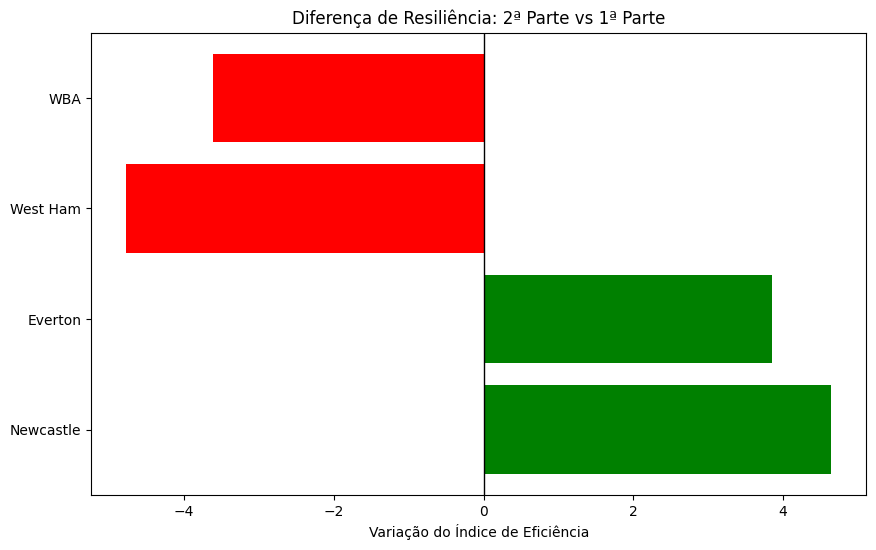

In [8]:
import matplotlib.pyplot as plt

# Dados fornecidos
adversarios = ['Newcastle', 'Everton', 'West Ham', 'WBA'] # Exemplo de contraste
diferenca = [4.64, 3.85, -4.77, -3.61]
cores = ['green' if x > 0 else 'red' for x in diferenca]

plt.figure(figsize=(10, 6))
plt.barh(adversarios, diferenca, color=cores)
plt.axvline(0, color='black', linewidth=1)
plt.title('Diferença de Resiliência: 2ª Parte vs 1ª Parte')
plt.xlabel('Variação do Índice de Eficiência')
plt.show()

In [9]:
# ==============================================================================
# 5. IDENTIFICANDO OS EXTREMOS DO MODELO (ESTUDOS DE CASO)
# ==============================================================================

# Ordena o DataFrame pelo Score Defensivo
df_defesa_sorted = df_defesa.sort_values(by='Score_Defensivo', ascending=False)

# Isola os Top 3 e Bottom 3
top_3_fortes = df_defesa_sorted.head(3)
top_3_fracas = df_defesa_sorted.tail(3)

print("🏆 TOP 3 DEFESAS FORTES (Estudos de Caso):")
for i, row in top_3_fortes.iterrows():
    print(f"- {row['Adversario']}: Score {row['Score_Defensivo']:.2f} | Gols Sofridos: {row['Gols_Sofridos_Adversario']}")

print("\n⚠️ TOP 3 DEFESAS FRACAS (Estudos de Caso):")
for i, row in top_3_fracas.iterrows():
    print(f"- {row['Adversario']}: Score {row['Score_Defensivo']:.2f} | Gols Sofridos: {row['Gols_Sofridos_Adversario']}")

🏆 TOP 3 DEFESAS FORTES (Estudos de Caso):
- Huddersfield Town: Score 3.36 | Gols Sofridos: 0
- Liverpool: Score 3.19 | Gols Sofridos: 3
- West Ham United: Score 3.02 | Gols Sofridos: 2

⚠️ TOP 3 DEFESAS FRACAS (Estudos de Caso):
- Crystal Palace: Score -2.84 | Gols Sofridos: 5
- Swansea City: Score -2.96 | Gols Sofridos: 5
- Swansea City: Score -3.45 | Gols Sofridos: 4


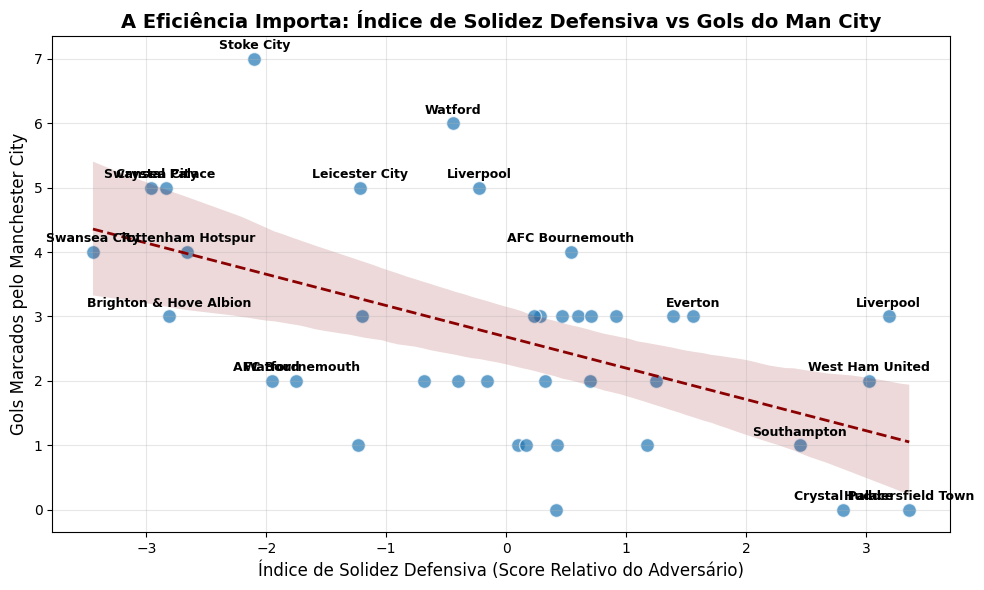

In [10]:
# ==============================================================================
# 6. GRÁFICO DE DISPERSÃO: SCORE DEFENSIVO VS GOLS MARCADOS
# ==============================================================================

plt.figure(figsize=(10, 6))

# Cria o scatter plot com linha de tendência (regressão linear)
sns.regplot(
    data=df_defesa, 
    x='Score_Defensivo', 
    y='Gols_Sofridos_Adversario',
    scatter_kws={'s': 100, 'alpha': 0.7, 'edgecolor': 'white', 'color': '#1f77b4'},
    line_kws={'color': 'darkred', 'lw': 2, 'linestyle': '--'}
)

plt.title("A Eficiência Importa: Índice de Solidez Defensiva vs Gols do Man City", fontsize=14, weight='bold')
plt.xlabel("Índice de Solidez Defensiva (Score Relativo do Adversário)", fontsize=12)
plt.ylabel("Gols Marcados pelo Manchester City", fontsize=12)

# Adiciona os nomes dos times que são "outliers" ou extremos para humanizar o gráfico
for i, row in df_defesa.iterrows():
    # Destaca times com score muito alto, muito baixo, ou que sofreram muitos gols
    if row['Score_Defensivo'] > 1.5 or row['Score_Defensivo'] < -1.5 or row['Gols_Sofridos_Adversario'] >= 4:
        plt.text(
            row['Score_Defensivo'], 
            row['Gols_Sofridos_Adversario'] + 0.15, 
            row['Adversario'], 
            fontsize=9, 
            ha='center',
            weight='bold'
        )

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

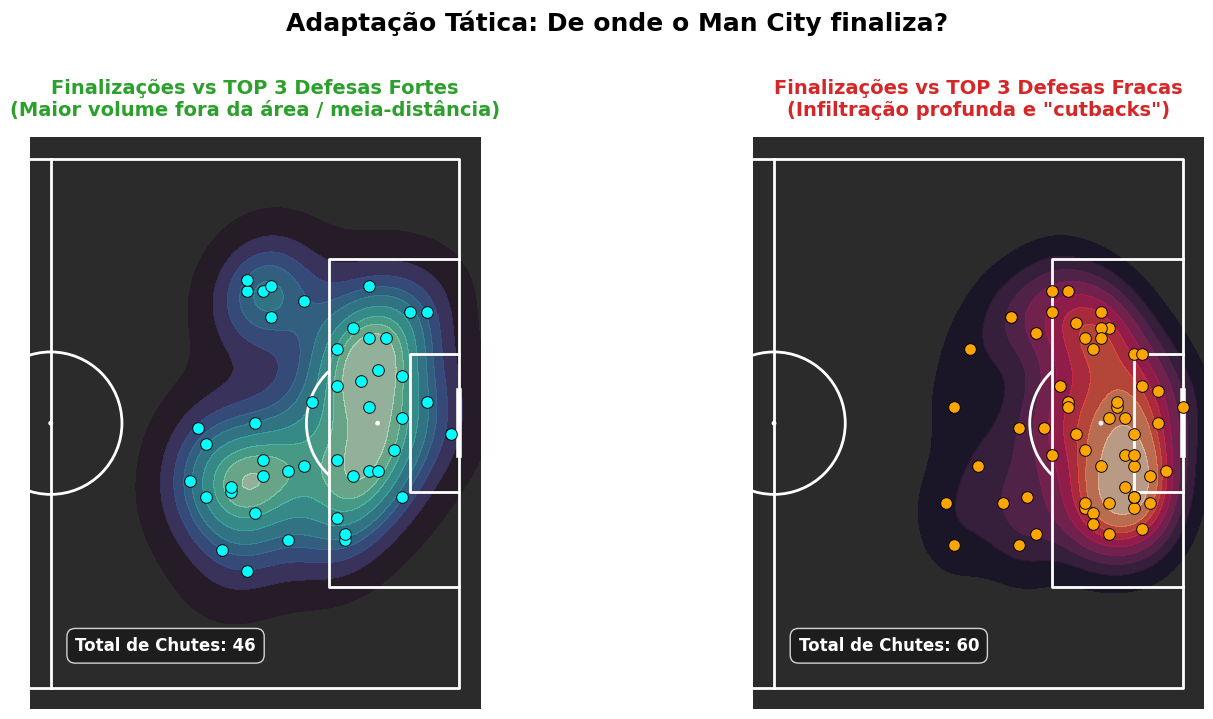

In [11]:
# ==============================================================================
# 7. MAPAS DE CALOR: ADAPTAÇÃO TÁTICA E ZONAS DE FINALIZAÇÃO (COM MPLSOCCER)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

# Captura os IDs dos jogos dos extremos
ids_fortes = top_3_fortes['matchId'].tolist()
ids_fracas = top_3_fracas['matchId'].tolist()

# Filtra apenas os chutes do City e extrai coordenadas
chutes_city = df_events[(df_events['teamId'] == CITY_ID) & (df_events['eventName'] == 'Shot')].copy()
chutes_city = extrai_coordenadas(chutes_city)

# Isola os chutes dados nos jogos contra o Top 3 Fortes e Top 3 Fracas
chutes_fortes = chutes_city[chutes_city['matchId'].isin(ids_fortes)]
chutes_fracas = chutes_city[chutes_city['matchId'].isin(ids_fracas)]

# Configura a figura lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Adaptação Tática: De onde o Man City finaliza?', fontsize=18, weight='bold', y=1.02)

# Cria o objeto do campo usando a biblioteca profissional (metade do campo, proporção wyscout)
pitch = Pitch(pitch_type='wyscout', half=True, pitch_color='#2b2b2b', line_color='white', line_zorder=2)

# Desenha o campo perfeito nos dois eixos
pitch.draw(ax=axes[0])
pitch.draw(ax=axes[1])

# Estilo para as caixinhas de texto dos contadores
box_style = dict(boxstyle="round,pad=0.5", facecolor="#1a1a1a", edgecolor="white", alpha=0.8, lw=1)

# --- GRÁFICO ESQUERDA: Contra Defesas Fortes ---
# Plot de Densidade KDE
sns.kdeplot(ax=axes[0], data=chutes_fortes, x='x', y='y', fill=True, cmap='mako', alpha=0.7, thresh=0.05, zorder=1)
# Plot exato dos chutes
sns.scatterplot(ax=axes[0], data=chutes_fortes, x='x', y='y', color='cyan', s=70, edgecolor='black', zorder=3)
axes[0].set_title('Finalizações vs TOP 3 Defesas Fortes\n(Maior volume fora da área / meia-distância)', 
                  fontsize=14, color='#2ca02c', weight='bold', pad=15)

# ADICIONANDO CONTADOR (ESQUERDA):
# Coordenadas do Wyscout para metade do campo vão de X: 50 a 100, e Y: 0 a 100.
# Posicionando no canto inferior esquerdo do mapa exibido (X=53, Y=93)
total_fortes = len(chutes_fortes)
axes[0].text(53, 93, f"Total de Chutes: {total_fortes}", color='white', fontsize=12,
             weight='bold', bbox=box_style, zorder=4)


# --- GRÁFICO DIREITA: Contra Defesas Fracas ---
# Plot de Densidade KDE
sns.kdeplot(ax=axes[1], data=chutes_fracas, x='x', y='y', fill=True, cmap='rocket', alpha=0.7, thresh=0.05, zorder=1)
# Plot exato dos chutes
sns.scatterplot(ax=axes[1], data=chutes_fracas, x='x', y='y', color='orange', s=70, edgecolor='black', zorder=3)
axes[1].set_title('Finalizações vs TOP 3 Defesas Fracas\n(Infiltração profunda e "cutbacks")', 
                  fontsize=14, color='#d62728', weight='bold', pad=15)

# ADICIONANDO CONTADOR (DIREITA):
total_fracas = len(chutes_fracas)
axes[1].text(53, 93, f"Total de Chutes: {total_fracas}", color='white', fontsize=12,
             weight='bold', bbox=box_style, zorder=4)

plt.tight_layout()
plt.show()

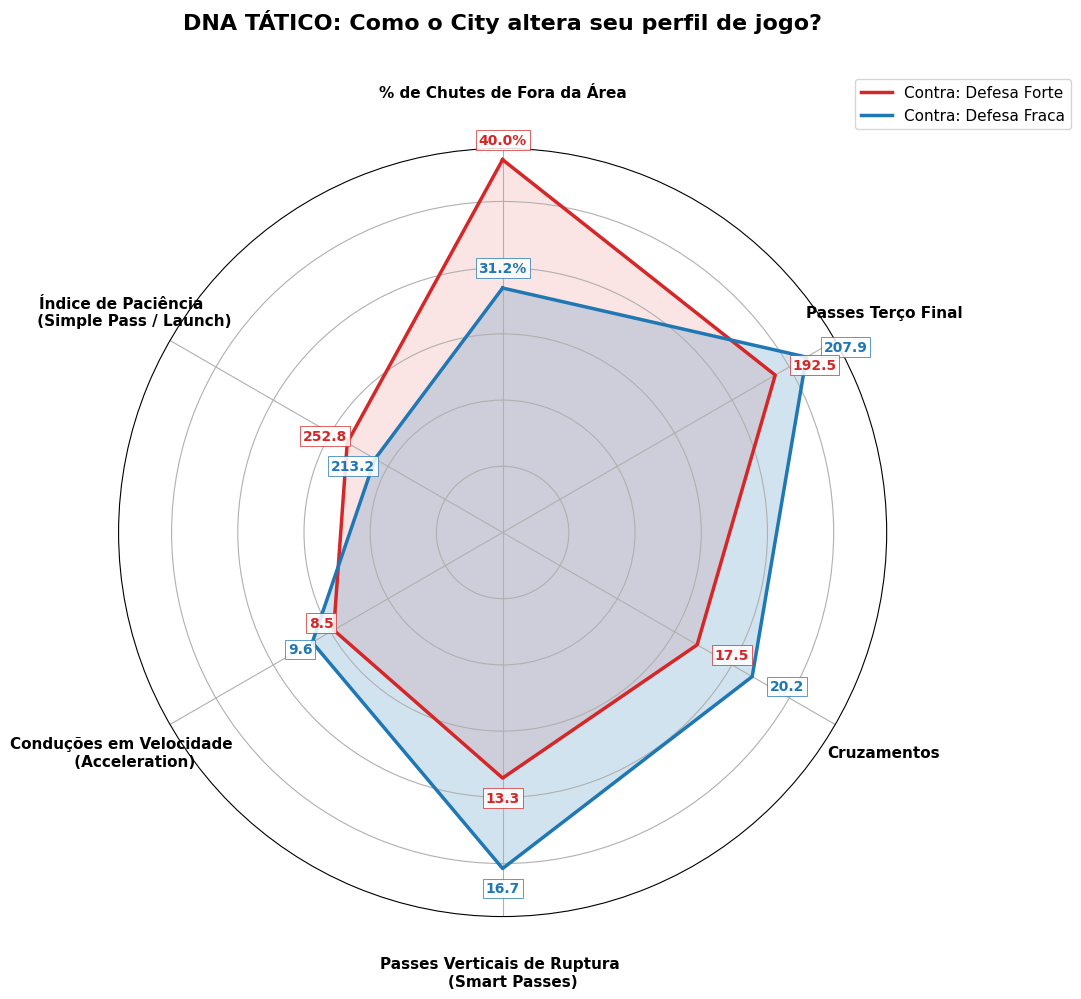

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# 10. GRÁFICO DE RADAR COMPLETO - SOLUÇÃO FINAL CONTRA KEYERROR
# ==============================================================================



dados_avancados = []

for m_id in df_defesa['matchId'].unique():
    jogo_df = df_events[df_events['matchId'] == m_id].copy()
    jogo_df = extrai_coordenadas(jogo_df)
    
    city_events = jogo_df[jogo_df['teamId'] == CITY_ID].copy()
    adversario_events = jogo_df[jogo_df['teamId'] != CITY_ID].copy()
    
    # 1. Geografia dos Passes no Terço Final
    passes_terco_final = city_events[(city_events['eventName'] == 'Pass') & (city_events['x'] > 66)]
    total_passes_tf = len(passes_terco_final)
    
    dir_passes = len(passes_terco_final[passes_terco_final['y'] < 25])
    cen_passes = len(passes_terco_final[(passes_terco_final['y'] >= 25) & (passes_terco_final['y'] <= 75)])
    esq_passes = len(passes_terco_final[passes_terco_final['y'] > 75]) 
    
    pct_dir = (dir_passes / total_passes_tf * 100) if total_passes_tf > 0 else 0
    pct_cen = (cen_passes / total_passes_tf * 100) if total_passes_tf > 0 else 0
    pct_esq = (esq_passes / total_passes_tf * 100) if total_passes_tf > 0 else 0
    
    bolas_paradas_ataque = len(city_events[(city_events['eventName'] == 'Free Kick') & (city_events['x'] > 60)])

    # 2. Chutes de Longe
    chutes = city_events[city_events['eventName'] == 'Shot']
    chutes_longe = len(chutes[chutes['x'] < 84])
    pct_chutes_longe = (chutes_longe / len(chutes) * 100) if len(chutes) > 0 else 0
    
    # 3. Cruzamentos
    cruzamentos = len(city_events[city_events['subEventName'] == 'Cross'])
    
    # 4. Circulação no Terço Final
    passes_terco_final = len(city_events[(city_events['eventName'] == 'Pass') & (city_events['x'] > 66)])
    
    # 5. Passes que Quebram Linhas (Smart Passes)
    smart_passes = len(city_events[city_events['subEventName'] == 'Smart pass'])
    
    # 6. Acelerações / Jogadas Individuais
    aceleracoes = len(city_events[city_events['subEventName'] == 'Acceleration'])
        
    # 7. Faltas Gerais do Jogo
    faltas_sofridas_total = len(adversario_events[adversario_events['subEventName'] == 'Foul'])
    faltas_cometidas_total = len(city_events[city_events['subEventName'] == 'Foul'])
    
    # 8. Métrica de Passes e o ÍNDICE DE PACIÊNCIA
    simples = len(city_events[city_events['subEventName'] == 'Simple pass'])
    lançamentos = len(city_events[city_events['subEventName'] == 'Launch'])
    indice_paciencia = (simples / lançamentos) if lançamentos > 0 else simples
    
    dados_avancados.append({
        'matchId': m_id,
        'Corredor Direito (%)': pct_dir,
        'Centro (%)': pct_cen,
        'Corredor Esquerdo (%)': pct_esq,
        'Bolas Paradas a Favor': bolas_paradas_ataque,
        'Faltas Sofridas': faltas_sofridas_total,
        'Faltas Cometidas': faltas_cometidas_total,
        'Indice_Paciencia': indice_paciencia,
        'Pct_Chutes_Longe': pct_chutes_longe,
        'Cruzamentos': cruzamentos,
        'Passes_Terco_Final': passes_terco_final,
        'Smart_Passes': smart_passes,
        'Acelerações': aceleracoes,
    })

df_avancado = pd.DataFrame(dados_avancados)

# ---> REESTRUTURAÇÃO DOS MERGES PARA EVITAR PERDA DE COLUNAS <---
# Primeiro, juntamos a classificação da defesa ao df_avancado
df_radar_completo = pd.merge(df_defesa[['matchId', 'Classificacao_Defesa']], df_avancado, on='matchId', how='left')


# Lista oficial de colunas para o agrupamento e cálculo
colunas_metricas = [
    'Pct_Chutes_Longe', 'Passes_Terco_Final', 'Cruzamentos',
    'Smart_Passes', 'Acelerações', 
    'Indice_Paciencia'
]

# Agrupamento pelas médias
resumo_radar = df_radar_completo.groupby('Classificacao_Defesa', observed=False)[colunas_metricas].mean().reset_index()

# NORMALIZAÇÃO MIN-MAX
df_norm = resumo_radar.copy()
for col in colunas_metricas:
    min_val = df_radar_completo[col].min()
    max_val = df_radar_completo[col].max()
    df_norm[col] = (resumo_radar[col] - min_val) / (max_val - min_val) if (max_val - min_val) > 0 else 0

# CONFIGURAÇÃO DA GEOMETRIA DO RADAR (9 variáveis)
labels = [
    '% de Chutes de Fora da Área', 'Passes Terço Final', 'Cruzamentos',
    """Passes Verticais de Ruptura 
    (Smart Passes)""", """Conduções em Velocidade
     (Acceleration)""", 
    """Índice de Paciência
     (Simple Pass / Launch)"""
]
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# --- 4. PLOTAGEM DO GRÁFICO DE RADAR COM VERIFICAÇÃO DE PROXIMIDADE ---
fig, ax = plt.subplots(figsize=(11, 11), subplot_kw=dict(polar=True))

perfis = {
    'Defesa Fraca': {'cor': '#1f77b4', 'label': 'Contra: Defesa Fraca', 'fill_alpha': 0.20},
    'Defesa Forte': {'cor': '#d62728', 'label': 'Contra: Defesa Forte', 'fill_alpha': 0.12}
}

# 1. Primeiro desenhamos as linhas e preenchimentos das duas classes normalmente
for classe in resumo_radar['Classificacao_Defesa'].unique():
    valores_norm = df_norm[df_norm['Classificacao_Defesa'] == classe][colunas_metricas].values[0].tolist()
    valores_norm += valores_norm[:1]
    ax.plot(angles, valores_norm, color=perfis[classe]['cor'], linewidth=2.5, label=perfis[classe]['label'])
    ax.fill(angles, valores_norm, color=perfis[classe]['cor'], alpha=perfis[classe]['fill_alpha'])

# 2. Extraímos os dados ordenados de cada classe para fazer a comparação direta
valores_fraca_norm = df_norm[df_norm['Classificacao_Defesa'] == 'Defesa Fraca'][colunas_metricas].values[0]
valores_fraca_real = resumo_radar[resumo_radar['Classificacao_Defesa'] == 'Defesa Fraca'][colunas_metricas].values[0]

valores_forte_norm = df_norm[df_norm['Classificacao_Defesa'] == 'Defesa Forte'][colunas_metricas].values[0]
valores_forte_real = resumo_radar[resumo_radar['Classificacao_Defesa'] == 'Defesa Forte'][colunas_metricas].values[0]

# 3. Loop por métrica (ângulo) verificando a proximidade antes de plotar o texto
for i in range(num_vars):
    angle = angles[i]
    col = colunas_metricas[i]
    
    # Valores normais (posição no gráfico) e reais (texto)
    norm_fraca = valores_fraca_norm[i]
    real_fraca = valores_fraca_real[i]
    
    norm_forte = valores_forte_norm[i]
    real_forte = valores_forte_real[i]
    
    # Formatação dos textos
    txt_fraca = f'{real_fraca:.1f}%' if col == 'Pct_Chutes_Longe' else f'{real_fraca:.1f}'
    txt_forte = f'{real_forte:.1f}%' if col == 'Pct_Chutes_Longe' else f'{real_forte:.1f}'
    
    # ---> AQUI ACONTECE A VERIFICAÇÃO DE PROXIMIDADE <---
    # Se a distância entre as linhas no gráfico for menor que 0.05 (muito perto ou igual)
    if abs(norm_fraca - norm_forte) < 0.05:
        # Força o Vermelho (Forte) para cima e o Azul (Fraca) para baixo da intersecção
        pos_forte = norm_forte
        va_forte = 'bottom'
        
        pos_fraca = norm_fraca 
        va_fraca = 'top'
    else:
        # Se os valores forem distantes, cada um fica na sua linha natural, ligeiramente para fora
        pos_forte = norm_forte + 0.03
        va_forte = 'center'
        
        pos_fraca = norm_fraca + 0.03
        va_fraca = 'center'
        
    # Alinhamento horizontal inteligente padrão para não chocar com o centro/laterais
    if np.isclose(angle, 0) or np.isclose(angle, np.pi):
        ha_txt = 'center'
    elif 0 < angle < np.pi:
        ha_txt = 'left'
    else:
        ha_txt = 'right'

    # Plota o texto da Defesa Fraca (Azul)
    ax.text(angle, pos_fraca, txt_fraca, color='#1f77b4', weight='bold', fontsize=10,
            ha=ha_txt, va=va_fraca, bbox=dict(facecolor='white', alpha=0.85, edgecolor='#1f77b4', lw=0.6, pad=2))
    
    # Plota o texto da Defesa Forte (Vermelho)
    ax.text(angle, pos_forte, txt_forte, color='#d62728', weight='bold', fontsize=10,
            ha=ha_txt, va=va_forte, bbox=dict(facecolor='white', alpha=0.85, edgecolor='#d62728', lw=0.6, pad=2))

# Ajustes finais dos ângulos e eixos
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11, weight='bold')
ax.tick_params(axis='x', pad=30)
ax.set_yticklabels([])

plt.title('DNA TÁTICO: Como o City altera seu perfil de jogo?', fontsize=16, weight='bold', pad=40)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

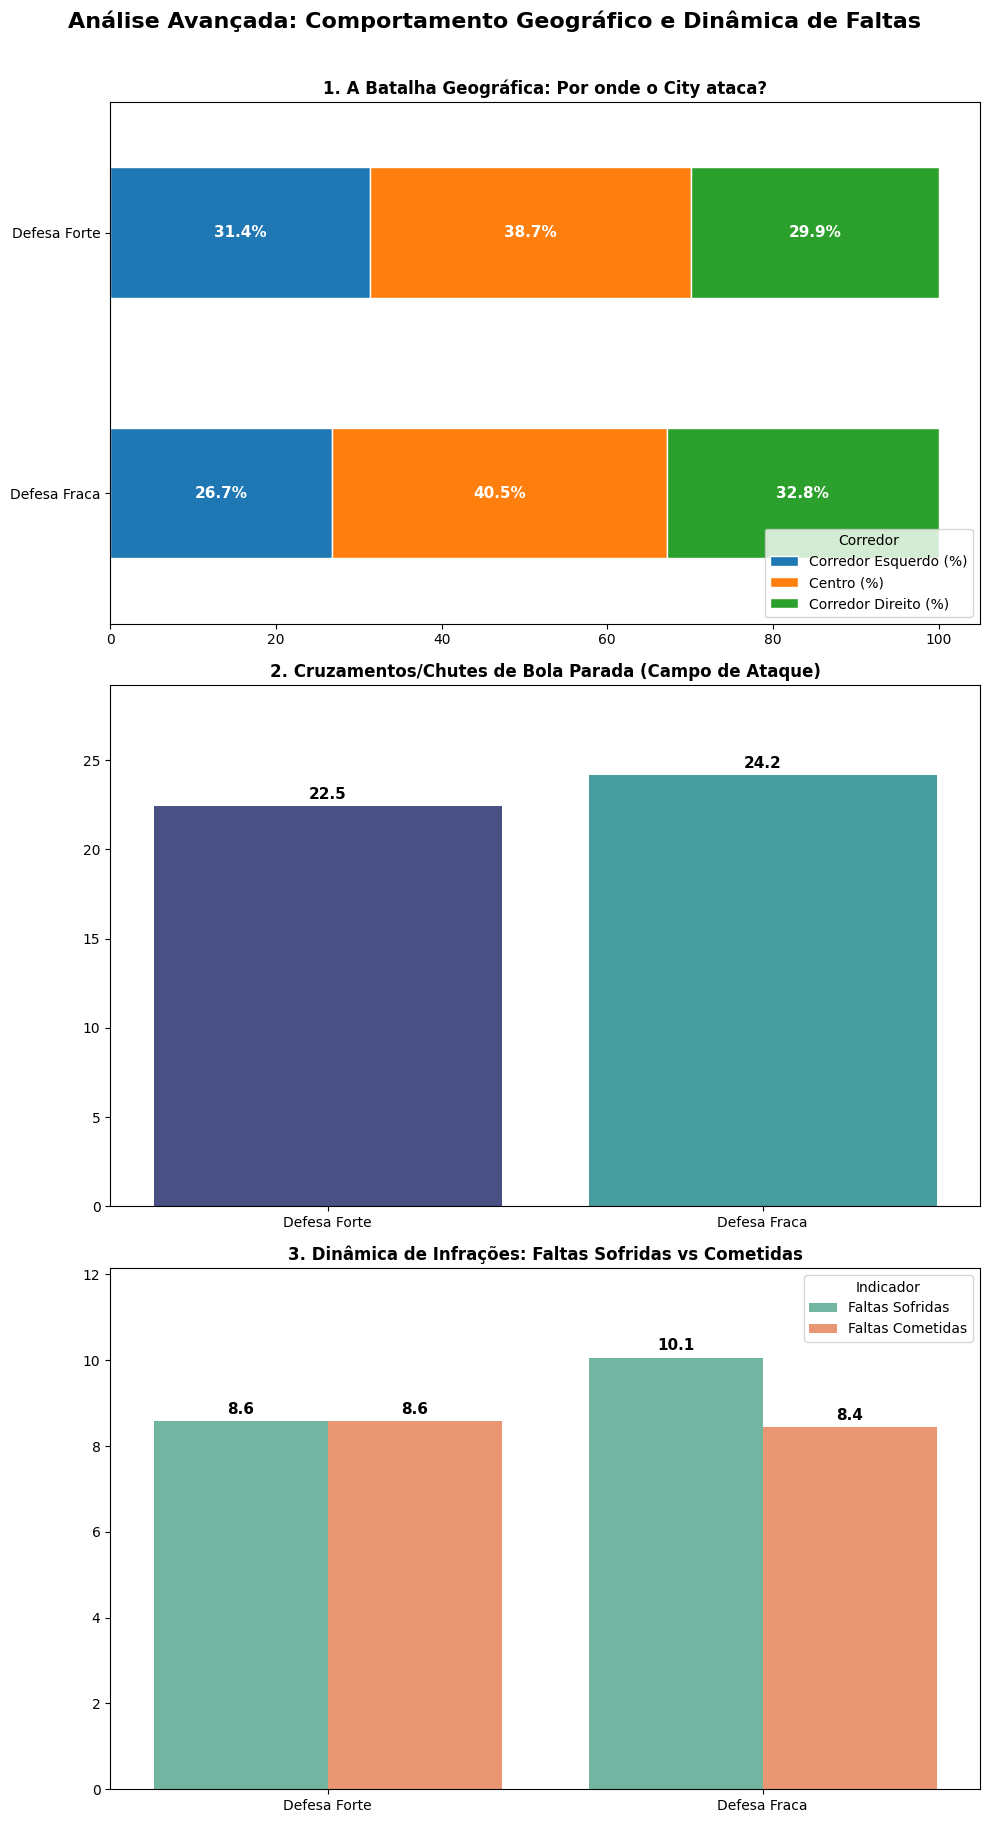

In [13]:
# ==============================================================================
# 9. ANÁLISES AVANÇADAS: GEOGRAFIA, FALTAS E TURNOVERS (UM EMBAIXO DO OUTRO)
# ==============================================================================

df_plot_avancado = pd.merge(df_defesa[['matchId', 'Classificacao_Defesa']], df_avancado, on='matchId')

# Reorganiza o DataFrame de faltas para o formato longo (ideal para o gráfico lado a lado)
df_faltas_long = pd.melt(
    df_plot_avancado, 
    id_vars=['Classificacao_Defesa'], 
    value_vars=['Faltas Sofridas', 'Faltas Cometidas'],
    var_name='Tipo_Falta', 
    value_name='Quantidade'
)

# Calcula as médias para os plots de barras simples
resumo_avancado_mean = df_plot_avancado.groupby('Classificacao_Defesa', observed=False).mean().reset_index()

# ==============================================================================
# LAYOUT CORRIGIDO: 3 Linhas e 1 Coluna (Alinhamento vertical perfeito)
# ==============================================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 18))
fig.suptitle('Análise Avançada: Comportamento Geográfico e Dinâmica de Faltas', fontsize=16, weight='bold', y=1.01)

# ------------------------------------------------------------------------------
# GRÁFICO 1: Batalha Geográfica (Barras Empilhadas)
# ------------------------------------------------------------------------------
resumo_geo = df_plot_avancado.groupby('Classificacao_Defesa', observed=False)[['Corredor Esquerdo (%)', 'Centro (%)', 'Corredor Direito (%)']].mean()
resumo_geo = resumo_geo.reindex(['Defesa Fraca', 'Defesa Forte'])
resumo_geo.plot(kind='barh', stacked=True, ax=axes[0], color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='white')

for container in axes[0].containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 0 else '' for v in container]
    axes[0].bar_label(container, labels=labels, label_type='center', color='white', weight='bold', fontsize=11)

axes[0].set_title('1. A Batalha Geográfica: Por onde o City ataca?', fontsize=12, weight='bold')
axes[0].set_xlabel('Proporção de Passes no Terço Final (%)')
axes[0].legend(title='Corredor', loc='lower right')

# ------------------------------------------------------------------------------
# GRÁFICO 2: Bolas Paradas Ofensivas (Barras Simples)
# ------------------------------------------------------------------------------
sns.barplot(ax=axes[1], data=resumo_avancado_mean, x='Classificacao_Defesa', y='Bolas Paradas a Favor', hue='Classificacao_Defesa', palette='mako', legend=False)
axes[1].set_title('2. Cruzamentos/Chutes de Bola Parada (Campo de Ataque)', fontsize=12, weight='bold')
axes[1].set_ylabel('Média por Jogo')
for c in axes[1].containers: axes[1].bar_label(c, fmt='%.1f', padding=3, weight='bold', size=11)

# ------------------------------------------------------------------------------
# GRÁFICO 3: O Balanço das Faltas (Sofridas vs Cometidas Lado a Lado)
# ------------------------------------------------------------------------------
sns.barplot(ax=axes[2], data=df_faltas_long, x='Classificacao_Defesa', y='Quantidade', hue='Tipo_Falta', palette='Set2', errorbar=None)
axes[2].set_title('3. Dinâmica de Infrações: Faltas Sofridas vs Cometidas', fontsize=12, weight='bold')
axes[2].set_ylabel('Média de Faltas por Jogo')
axes[2].legend(title='Indicador')
for c in axes[2].containers: axes[2].bar_label(c, fmt='%.1f', padding=3, weight='bold', size=11)


# Limpeza visual dos eixos e aplicação do teto de respiro para os rótulos não cortarem
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('')
    if ax != axes[0]:  # Adiciona margem no topo apenas nos gráficos de barras verticais
        ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

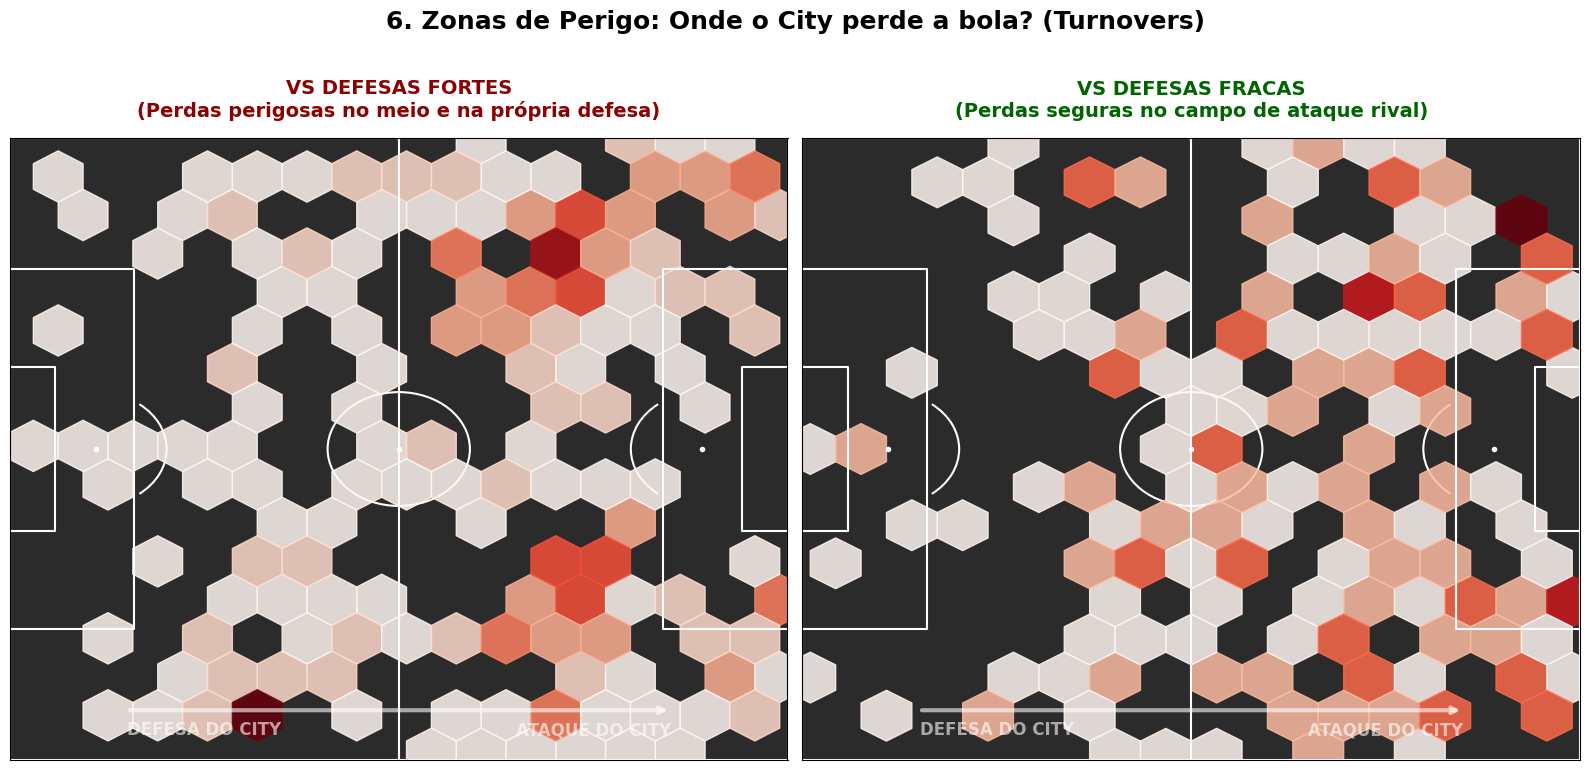

In [14]:
import matplotlib.patches as patches

# --- PLOTAGEM 3: TURNOVERS (HEXBIN PLOT COM CAMPO DETALHADO E LABELS) ---

# Função avançada para desenhar o campo do Wyscout (0 a 100)
def desenha_campo_wyscout(ax, cor_fundo='#2b2b2b', cor_linha='white'):
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_facecolor(cor_fundo)
    
    # Contorno externo do campo e Linha de meio campo
    ax.plot([0, 100, 100, 0, 0], [0, 0, 100, 100, 0], color=cor_linha, lw=1.5)
    ax.plot([50, 50], [0, 100], color=cor_linha, lw=1.5)
    
    # Círculo central e ponto central
    centro = patches.Circle((50, 50), 9.15, fill=False, edgecolor=cor_linha, lw=1.5)
    ax.add_patch(centro)
    ax.plot(50, 50, 'o', color=cor_linha, markersize=3)
    
    # DEFESA ESQUERDA
    ax.plot([0, 16, 16, 0], [21.1, 21.1, 78.9, 78.9], color=cor_linha, lw=1.5) # Grande Área
    ax.plot([0, 5.8, 5.8, 0], [36.8, 36.8, 63.2, 63.2], color=cor_linha, lw=1.5) # Pequena Área
    ax.plot(11, 50, 'o', color=cor_linha, markersize=3) # Pênalti
    arco_esq = patches.Arc((11, 50), 18.3, 18.3, angle=0, theta1=308, theta2=52, color=cor_linha, lw=1.5)
    ax.add_patch(arco_esq)
    
    # DEFESA DIREITA (Ataque do City)
    ax.plot([100, 84, 84, 100], [21.1, 21.1, 78.9, 78.9], color=cor_linha, lw=1.5) # Grande Área
    ax.plot([100, 94.2, 94.2, 100], [36.8, 36.8, 63.2, 63.2], color=cor_linha, lw=1.5) # Pequena Área
    ax.plot(89, 50, 'o', color=cor_linha, markersize=3) # Pênalti
    arco_dir = patches.Arc((89, 50), 18.3, 18.3, angle=180, theta1=308, theta2=52, color=cor_linha, lw=1.5)
    ax.add_patch(arco_dir)
    
    # --- ADIÇÃO DOS LABELS GEOGRÁFICOS ---
    # Textos no gramado indicando Ataque e Defesa
    ax.text(25, 4, "DEFESA DO CITY", color='white', alpha=0.6, fontsize=12, ha='center', weight='bold')
    ax.text(75, 4, "ATAQUE DO CITY", color='white', alpha=0.6, fontsize=12, ha='center', weight='bold')
    
    # Seta indicando o sentido de ataque do Man City
    ax.annotate('', xy=(85, 8), xytext=(15, 8),
                arrowprops=dict(arrowstyle="->", color='white', alpha=0.6, lw=3))
    
    # Limpeza dos eixos
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

# Função para extrair passes errados
def passes_errados(df_jogos, match_ids):
    df_filtrado = df_jogos[df_jogos['matchId'].isin(match_ids)].copy()
    df_filtrado = extrai_coordenadas(df_filtrado)
    passes = df_filtrado[(df_filtrado['teamId'] == CITY_ID) & (df_filtrado['eventName'] == 'Pass')].copy()
    passes['sucesso'] = passes['tags'].apply(lambda tags: 1 if isinstance(tags, list) and any(t.get('id') == 1801 for t in tags) else 0)
    return passes[passes['sucesso'] == 0]

# Extrai os dados
erros_fortes = passes_errados(df_events, top_3_fortes['matchId'].tolist())
erros_fracas = passes_errados(df_events, top_3_fracas['matchId'].tolist())

# Configuração da Imagem
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), sharey=True, sharex=True)
fig.suptitle('6. Zonas de Perigo: Onde o City perde a bola? (Turnovers)', fontsize=18, weight='bold', y=1.02)

# Gráfico 1: Contra Defesas Fortes
desenha_campo_wyscout(axes[0])
hb1 = axes[0].hexbin(erros_fortes['x'], erros_fortes['y'], gridsize=15, cmap='Reds', mincnt=1, alpha=0.85)
# Título grande acima do campo
axes[0].set_title('VS DEFESAS FORTES\n(Perdas perigosas no meio e na própria defesa)', fontsize=14, color='darkred', weight='bold', pad=15)

# Gráfico 2: Contra Defesas Fracas
desenha_campo_wyscout(axes[1])
hb2 = axes[1].hexbin(erros_fracas['x'], erros_fracas['y'], gridsize=15, cmap='Reds', mincnt=1, alpha=0.85)
# Título grande acima do campo
axes[1].set_title('VS DEFESAS FRACAS\n(Perdas seguras no campo de ataque rival)', fontsize=14, color='darkgreen', weight='bold', pad=15)

plt.tight_layout()
plt.show()


🎯 ESTUDOS DE CASO: EXTREMOS DO MODELO


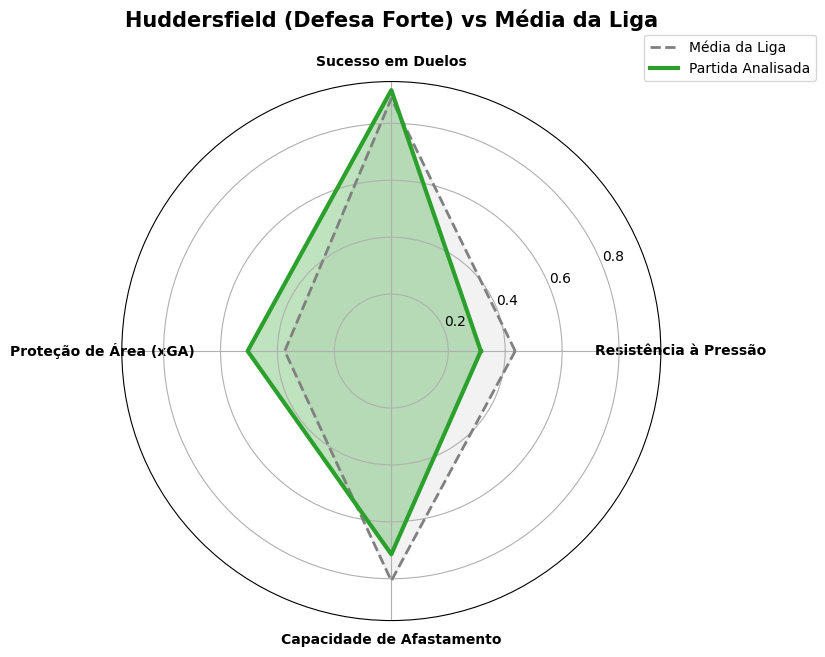

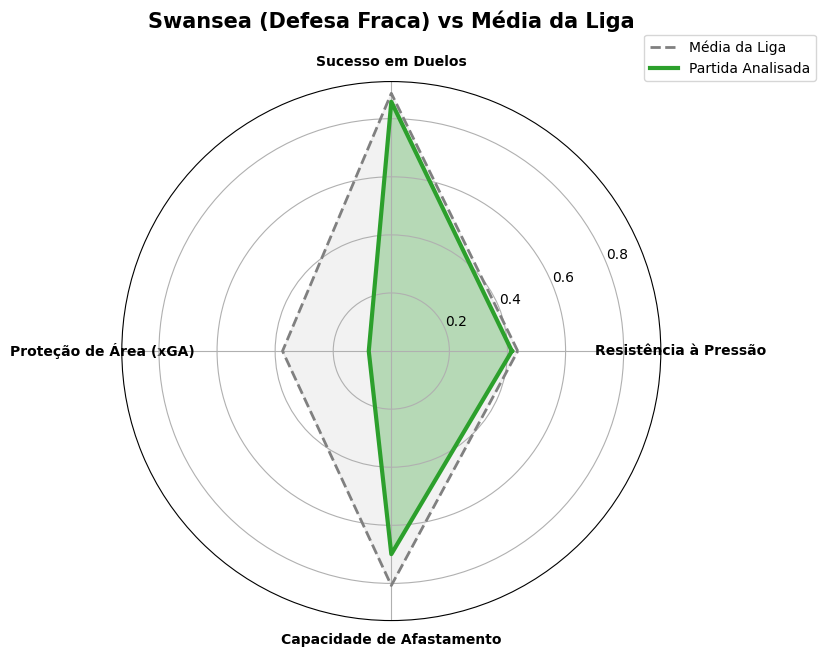

In [15]:
def criar_radar_defensivo(match_id_estudo, df_base, titulo):
    """
    Cria um radar chart comparando performance de jogo específico vs média da liga.
    
    Args:
        match_id_estudo (int): ID do jogo Wyscout a comparar
        df_base (DataFrame): DataFrame com dados de todos os jogos
        titulo (str): Título do gráfico
        
    Interpretação:
        - Polígono fora da área cinzenta = desempenho ACIMA da média
        - Polígono dentro = desempenho ABAIXO da média
    """
    dados_jogo = df_base[df_base['matchId'] == match_id_estudo].iloc[0]
    media_geral = df_base[['PPDA_Adversario', 'Sucesso_Duelos_Def_Adv', 'xGA_Acumulado_Adversario', 'Distancia_Media_Chutes_City']].mean()
    
    # Transformando dados brutos em "Índices de Eficiência" (0 a 1)
    # IMPORTANTE: Tudo fica "quanto maior, melhor"
    jogo_indices = [
        1 - (dados_jogo['PPDA_Adversario'] / df_base['PPDA_Adversario'].max()),  # Anular pressão
        (dados_jogo['Sucesso_Duelos_Def_Adv'] / df_base['Sucesso_Duelos_Def_Adv'].max()),  # Sucesso em duelos
        1 - (dados_jogo['xGA_Acumulado_Adversario'] / df_base['xGA_Acumulado_Adversario'].max()),  # Proteção área
        (dados_jogo['Distancia_Media_Chutes_City'] / df_base['Distancia_Media_Chutes_City'].max())  # Afastamento
    ]
    
    media_indices = [
        1 - (media_geral['PPDA_Adversario'] / df_base['PPDA_Adversario'].max()),
        (media_geral['Sucesso_Duelos_Def_Adv'] / df_base['Sucesso_Duelos_Def_Adv'].max()),
        1 - (media_geral['xGA_Acumulado_Adversario'] / df_base['xGA_Acumulado_Adversario'].max()),
        (media_geral['Distancia_Media_Chutes_City'] / df_base['Distancia_Media_Chutes_City'].max())
    ]

    labels = ['Resistência à Pressão', 'Sucesso em Duelos', 'Proteção de Área (xGA)', 'Capacidade de Afastamento']
    
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    jogo_indices = np.concatenate((jogo_indices, [jogo_indices[0]]))
    media_indices = np.concatenate((media_indices, [media_indices[0]]))
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    
    ax.plot(angles, media_indices, color='gray', linewidth=2, linestyle='--', label='Média da Liga')
    ax.fill(angles, media_indices, color='gray', alpha=0.1)
    
    ax.plot(angles, jogo_indices, color='#2ca02c', linewidth=3, label='Partida Analisada')
    ax.fill(angles, jogo_indices, color='#2ca02c', alpha=0.3)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontweight='bold')
    ax.set_title(titulo, size=15, weight='bold', pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    plt.show()


# Exemplos de estudos de caso (Extremos do modelo)
print("\n" + "="*80)
print("🎯 ESTUDOS DE CASO: EXTREMOS DO MODELO")
print("="*80)

id_huddersfield = df_defesa[df_defesa['Adversario'] == 'Huddersfield Town']['matchId'].iloc[0]
criar_radar_defensivo(id_huddersfield, df_defesa, "Huddersfield (Defesa Forte) vs Média da Liga")

id_swansea = df_defesa[df_defesa['Adversario'] == 'Swansea City']['matchId'].iloc[0]
criar_radar_defensivo(id_swansea, df_defesa, "Swansea (Defesa Fraca) vs Média da Liga")

In [ ]:
# ==============================================================================
# RELATÓRIO FINAL: RESUMO DAS ESTATÍSTICAS PARA INCORPORAÇÃO NO ARTIGO
# ==============================================================================

print("\n" + "="*80)
print("📋 RESUMO FINAL PARA INCORPORAÇÃO NO ARTIGO")
print("="*80)

print("\n📊 VALORES DE ESTATÍSTICA INFERENCIAL:")
print(f"   • N (amostra total): {len(df_defesa)}")
print(f"   • Pearson r: {stats_modelo['pearson_r']:.4f}")
print(f"   • Pearson p-value: {stats_modelo['pearson_p']:.4f}")
print(f"   • Spearman ρ: {stats_modelo['spearman_rho']:.4f}")
print(f"   • Spearman p-value: {stats_modelo['spearman_p']:.4f}")
print(f"   • R² (coeficiente determinação): {stats_modelo['r2']:.4f}")
print(f"   • Percentual explicado: {stats_modelo['r2']*100:.1f}%")

print("\n📈 EQUAÇÃO DE REGRESSÃO:")
intercept = stats_modelo['modelo_lr'].intercept_
coef = stats_modelo['modelo_lr'].coef_[0]
print(f"   Gols_Sofridos = {intercept:.3f} + ({coef:.3f} × Score_Defensivo)")
print(f"   → A cada +1.0 no Score, City marca ~{abs(coef):.2f} gols menos")

print("\n🎯 TAMANHO DE AMOSTRA POR CATEGORIA:")
print(df_defesa['Classificacao_Defesa'].value_counts().sort_index())

print("\n✅ ESTATÍSTICAS DESCRITIVAS POR CATEGORIA:")
resumo_stats = df_defesa.groupby('Classificacao_Defesa', observed=False).agg({
    'Gols_Sofridos_Adversario': ['mean', 'std'],
    'Score_Defensivo': ['mean', 'std'],
    'xGA_Acumulado_Adversario': 'mean',
    'Sucesso_Duelos_Def_Adv': 'mean'
})

resumo_stats



📋 RESUMO FINAL PARA INCORPORAÇÃO NO ARTIGO

📊 VALORES DE ESTATÍSTICA INFERENCIAL:
   • N (amostra total): 38
   • Pearson r: -0.5213
   • Pearson p-value: 0.0008
   • Spearman ρ: -0.4436
   • Spearman p-value: 0.0053
   • R² (coeficiente determinação): 0.2717
   • Percentual explicado: 27.2%

📈 EQUAÇÃO DE REGRESSÃO:
   Gols_Sofridos = 2.684 + (-0.486 × Score_Defensivo)
   → A cada +1.0 no Score, City marca ~0.49 gols menos

🎯 TAMANHO DE AMOSTRA POR CATEGORIA:
Classificacao_Defesa
Defesa Forte    22
Defesa Fraca    16
Name: count, dtype: int64

✅ ESTATÍSTICAS DESCRITIVAS POR CATEGORIA:


Gols_Sofridos_Adversario           Score_Defensivo  \
                                         mean       std            mean   
Classificacao_Defesa                                                      
Defesa Forte                            2.000  1.195229        1.185432   
Defesa Fraca                            3.625  1.746425       -1.629968   

                               xGA_Acumulado_Adversario Sucesso_Duelos_Def_Adv  
                           std                     mean                   mean  
Classificacao_Defesa                                                            
Defesa Forte          1.074318                 2.763636              58.865543  
Defesa Fraca          1.088848                 3.850000              56.517152